<a href="https://colab.research.google.com/github/AiRenad/SatIQ_RQ2_Expanded_Experiments/blob/main/SatIQ_RQ2_Expanded_Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RQ2 — Comparing similarity functions
How do different similarity functions affect Siamese transmitter verification?

We're comparing SatIQ angular/cosine distance, Euclidean distance, and a positive-negative margin score. The encoder stays fixed. We use the same signals, identities, anchors and queries for every method so the comparison is fair.

The SatIQ comparison is preliminary because membership in the original encoder's training data is unresolved. Validation and test queries are separated here, but this does not erase earlier encoder training. This is RQ2 exploration, not completed RQ1 reproduction.

Heba's dataset gets a real compatibility audit. We do not feed arbitrary IQ chunks into SatIQ or claim attack detection unless its input format and transmitter mapping are verified. The notebook finishes with an explicit compatibility decision.


In [14]:
print("1/8 — Loading basic libraries...", flush=True)
from pathlib import Path
import sys, json, hashlib, tarfile, shutil, time, zipfile, platform

print("2/8 — Loading NumPy and pandas...", flush=True)
import numpy as np
import pandas as pd

print("3/8 — Loading download and file libraries...", flush=True)
import requests
import h5py
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

print("4/8 — Loading TensorFlow...", flush=True)
import tensorflow as tf

print("5/8 — Loading Keras...", flush=True)
from tensorflow.keras import layers, Model

print("6/8 — Loading metrics and plotting libraries...", flush=True)
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from IPython.display import display, FileLink

print("7/8 — Preparing folders and settings...", flush=True)
ROOT = Path("/content/SatIQ") if Path("/content").exists() else Path.cwd() / "SatIQ"
DATA = ROOT / "data"
OUT = ROOT / "rq2_results"

for folder in [DATA, OUT, DATA / "models"]:
    folder.mkdir(parents=True, exist_ok=True)

K_VALUES = [1, 2, 4, 8, 16, 32, 64]  # automatically reduced later if the selected temporal reference pool cannot support a value
ANCHOR_SEEDS = [0, 1, 2, 3, 4]
MAX_IDENTITIES = 100
QUERIES_PER_ID = 2
TARGET_VALIDATION_FAR = 0.01
HEBA_COMMIT = "cc12cd9e49553b2a3009b7d08f9e5615b7f6fa35"
HEBA_REPO = "JosWigchert/AerialSpoofingDetectonDataset"
HEBA_AUDIT = True
SEED = 42
BATCH_SIZE = 32
MODEL_MD5 = "e40d715441dc1241dc43b4bfdaf573f5"
COMMIT = "1805a77b33d8fd7723997be85c783ddf24d996d0"

print("8/8 — Checking GPU...", flush=True)
gpus = tf.config.list_physical_devices("GPU")

print("Python:", platform.python_version())
print("TensorFlow:", tf.__version__)
print("GPUs:", gpus)
print("Results folder:", OUT)

if not gpus:
    print("CPU runtime: calculations will work but may take longer.")

print("Setup completed.", flush=True)

1/8 — Loading basic libraries...
2/8 — Loading NumPy and pandas...
3/8 — Loading download and file libraries...
4/8 — Loading TensorFlow...
5/8 — Loading Keras...
6/8 — Loading metrics and plotting libraries...
7/8 — Preparing folders and settings...
8/8 — Checking GPU...
Python: 3.13.15
TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Results folder: /content/SatIQ/rq2_results
Setup completed.


Preparing downloads with retries and reuse of complete files. The model checksum is checked against Zenodo. A partial download is kept under a .part filename, so it is not mistaken for a finished file. If a server stays unavailable the cell stops with a clear error; rerun it later.


In [15]:
session = requests.Session()
session.mount('https://', HTTPAdapter(max_retries=Retry(
    total=3, backoff_factor=2, status_forcelist=[429, 500, 502, 503, 504],
    allowed_methods=['GET'])))

def md5_file(path):
    digest = hashlib.md5()
    with open(path, 'rb') as f:
        for chunk in iter(lambda: f.read(8 * 1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

def download(url, path, expected_md5=None):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists() and path.stat().st_size > 0:
        if expected_md5 is None or md5_file(path) == expected_md5:
            print('Using existing:', path.name)
            return path
        raise ValueError(f'Checksum mismatch: {path}. Remove this corrupt file and rerun.')
    part = path.with_name(path.name + '.part')
    for attempt in range(3):
        offset = part.stat().st_size if part.exists() else 0
        try:
            with session.get(url, headers={'Range': f'bytes={offset}-'} if offset else {},
                             stream=True, timeout=(30, 180)) as response:
                response.raise_for_status()
                resumed = offset > 0 and response.status_code == 206
                if resumed and not response.headers.get('Content-Range', '').startswith(f'bytes {offset}-'):
                    raise RuntimeError('Unexpected resume offset from server')
                with open(part, 'ab' if resumed else 'wb') as f:
                    for chunk in response.iter_content(4 * 1024 * 1024):
                        if chunk:
                            f.write(chunk)
            if expected_md5 and md5_file(part) != expected_md5:
                part.unlink()
                raise ValueError('Downloaded checksum does not match the published model')
            part.replace(path)
            print('Downloaded:', path.name, round(path.stat().st_size / 1e9, 3), 'GB')
            return path
        except (requests.RequestException, OSError) as error:
            if attempt == 2:
                raise RuntimeError(f'Download failed for {path.name}. Rerun this cell later.') from error
            time.sleep(2 * (attempt + 1))


Checking Heba's files before deciding whether they can be used for this exact verification task. We inspect the binary IQ files as complex64, as specified in the dataset README, and count the IQ pairs in the accompanying RAW+IQ text records.

We only use the individual spoofing scenario folders. All Scenarios repeats those files, so including both would duplicate data. The raw RAW+IQ prefix I: is not assumed to be a satellite identity.

Being Iridium data is not enough: SatIQ expects an aligned high-sample-rate header for each message, together with transmitter identity labels. Arbitrary concatenation, padding or interpolation cannot establish that compatibility.

Sources: [Heba's dataset](https://github.com/JosWigchert/AerialSpoofingDetectonDataset), [her paper, Sections V and VI](https://arxiv.org/html/2412.16008v1). Her paper builds IQ histograms and a sparse autoencoder; this is a different input representation from SatIQ.


In [16]:
from urllib.parse import quote
import re
heba_status = 'Not audited'
heba_dir = DATA / 'heba_audit'
heba_dir.mkdir(exist_ok=True)
heba_inventory = pd.DataFrame()
if HEBA_AUDIT:
    try:
        tree_path = heba_dir / f'tree_{HEBA_COMMIT}.json'
        if tree_path.exists():
            tree = json.loads(tree_path.read_text())
        else:
            response = session.get(f'https://api.github.com/repos/{HEBA_REPO}/git/trees/{HEBA_COMMIT}',
                                   params={'recursive':1}, timeout=60)
            response.raise_for_status(); tree = response.json()
            assert not tree.get('truncated'), 'Incomplete repository inventory'
            tree_path.write_text(json.dumps(tree))
        blobs = [x for x in tree['tree'] if x['type']=='blob']
        inventory = []
        for item in blobs:
            path = item['path']
            if not path.endswith('.bits.iq') or '/All Scenarios/' in path:
                continue
            target = heba_dir / path
            if target.exists() and target.stat().st_size != item['size']:
                raise ValueError(f'Incomplete existing file: {target}')
            download(f'https://raw.githubusercontent.com/{HEBA_REPO}/{HEBA_COMMIT}/{quote(path, safe="/")}',target)
            assert target.stat().st_size == item['size']
            iq = np.fromfile(target,dtype=np.complex64)
            assert target.stat().st_size % 8 == 0 and np.isfinite(iq).all()
            inventory.append(dict(path=path,label='benign' if path.startswith('Benign/') else 'spoofed',
                                  scenario=path.split('/')[1] if path.startswith('Spoofed/') else 'Benign',
                                  bytes=item['size'],iq_samples=len(iq),sha256=hashlib.sha256(target.read_bytes()).hexdigest()))
        heba_inventory = pd.DataFrame(inventory)
        assert len(heba_inventory)>0, 'No IQ files found'
        heba_inventory.to_csv(OUT/'heba_inventory.csv',index=False)
        duplicates = int(heba_inventory.duplicated('sha256').sum())
        # Inspect one benign and one attack recording, not every text file.
        examples = [heba_inventory[heba_inventory.label==label].iloc[0].path for label in ['benign','spoofed']]
        parsed = []
        for iq_path in examples:
            text_path = iq_path.replace('/iq/','/')[:-3]
            text_target = heba_dir / text_path
            download(f'https://raw.githubusercontent.com/{HEBA_REPO}/{HEBA_COMMIT}/{quote(text_path,safe="/")}',text_target)
            lines = text_target.read_text(errors='replace').splitlines()
            counts = [len(re.findall(r'\([^()]+,[^()]+\)',line)) for line in lines if line.startswith('RAW+IQ:')]
            parsed.append(dict(file=text_path,records=len(counts),
                               min_IQ_pairs=min(counts) if counts else None,
                               median_IQ_pairs=float(np.median(counts)) if counts else None,
                               max_IQ_pairs=max(counts) if counts else None))
        heba_records = pd.DataFrame(parsed)
        heba_records.to_csv(OUT/'heba_record_lengths.csv',index=False)
        display(heba_inventory.groupby(['label','scenario']).agg(files=('path','count'),IQ_samples=('iq_samples','sum')))
        display(heba_records)
        print('Duplicate content among selected IQ files:',duplicates)
        heba_status = ('NOT CLEARED for direct SatIQ inference: per-message 11000-sample header alignment, '
                       'sampling-rate compatibility and trusted/claimed satellite-cell identities are not established. '
                       'The binary benign/spoofed labels alone cannot supply positive/negative identity reference banks.')
    except (requests.RequestException, RuntimeError, OSError, ValueError, KeyError, AssertionError) as error:
        heba_status = 'AUDIT INCOMPLETE: ' + str(error)
print(heba_status)
(OUT/'heba_compatibility.txt').write_text(heba_status)
print('No Heba spoof-detection metrics will be generated from an unverified adapter.')


Downloaded: sat_data_jun_1_01.bits.iq 0.0 GB
Downloaded: sat_data_jun_2_01.bits.iq 0.002 GB
Downloaded: sat_data_may_26.bits.iq 0.001 GB
Downloaded: sat_data_may_26_02.bits.iq 0.003 GB
Downloaded: sat_data_may_26_03.bits.iq 0.001 GB
Downloaded: outdoor-10m.bits.iq 0.0 GB
Downloaded: outdoor-120m.bits.iq 0.0 GB
Downloaded: outdoor-30m.bits.iq 0.0 GB
Downloaded: outdoor-50m.bits.iq 0.0 GB
Downloaded: outdoor-70m.bits.iq 0.0 GB
Downloaded: outdoor-90m.bits.iq 0.001 GB
Downloaded: outdoor-120m-moving_tx.bits.iq 0.001 GB
Downloaded: outdoor-30m-moving_tx.bits.iq 0.0 GB
Downloaded: outdoor-70m-moving_tx.bits.iq 0.001 GB
Downloaded: outdoor-120m-moving_tx-rx.bits.iq 0.0 GB
Downloaded: outdoor-30m-moving_tx-rx.bits.iq 0.0 GB
Downloaded: outdoor-70m-moving_tx-rx.bits.iq 0.0 GB
Downloaded: sat_data_jun_1_01.bits 0.002 GB
Downloaded: outdoor-10m.bits 0.002 GB


files  IQ_samples
label   scenario                                      
benign  Benign                           5     1012927
spoofed Scenario 1 ~ Static              6      348988
        Scenario 2 ~ Moving TX           3      190046
        Scenario 3 ~ Moving TX & RX      3      148249

,file,records,min_IQ_pairs,median_IQ_pairs,max_IQ_pairs
0,Benign/sat_data_jun_1_01.bits,1005,12,48.0,181
1,Spoofed/Scenario 1 ~ Static/outdoor-10m.bits,1110,12,40.0,191


Duplicate content among selected IQ files: 0
NOT CLEARED for direct SatIQ inference: per-message 11000-sample header alignment, sampling-rate compatibility and trusted/claimed satellite-cell identities are not established. The binary benign/spoofed labels alone cannot supply positive/negative identity reference banks.
No Heba spoof-detection metrics will be generated from an unverified adapter.


Loading SatIQ's released pretrained encoder and data. The model is fixed throughout RQ2. We do not retrain it or change its weights to improve a particular similarity function.


In [17]:
from urllib.parse import quote

def get_zenodo_file(record_id, filename, destination, checksum):
    destination = Path(destination)

    # Reuse a verified copy from this Colab runtime.
    candidates = [destination]
    candidates += [
        p for p in Path("/content").rglob(filename)
        if p != destination and "drive" not in p.parts
    ]

    for candidate in candidates:
        if candidate.is_file() and md5_file(candidate) == checksum:
            print("Using verified file:", candidate, flush=True)
            return candidate

    if destination.exists():
        raise RuntimeError(
            f"{destination} has an incorrect checksum. "
            "Rename it before rerunning this cell."
        )

    # Ask Zenodo for the download URL.
    urls = []
    try:
        response = requests.get(
            f"https://zenodo.org/api/records/{record_id}",
            timeout=(20, 60)
        )
        response.raise_for_status()
        entry = next(
            item for item in response.json()["files"]
            if item["key"] == filename
        )
        api_url = entry.get("links", {}).get("self")
        if api_url:
            urls.append(api_url)
    except (requests.RequestException, KeyError, ValueError, StopIteration):
        print("API unavailable; trying the direct link.", flush=True)

    urls.append(
        f"https://zenodo.org/records/{record_id}/files/"
        f"{quote(filename)}?download=1"
    )

    last_error = None
    for url in dict.fromkeys(urls):
        print("Downloading:", filename, flush=True)
        print("URL:", url, flush=True)
        try:
            return download(url, destination, checksum)
        except RuntimeError as error:
            last_error = error
            print("This link failed; checking the next option.", flush=True)

    raise RuntimeError(
        f"Could not download {filename} from Zenodo. "
        "Keep the runtime open and rerun this cell later. "
        "Completed downloads will be reused."
    ) from last_error


model_path = get_zenodo_file(
    "8298532",
    "ae-triplet-final.h5",
    DATA / "models" / "ae-triplet-final.h5",
    MODEL_MD5
)

with h5py.File(model_path, "r") as f:
    config = json.loads(f.attrs["model_config"])
    print("Saved Keras version:", f.attrs["keras_version"])

archive_checksums = {
    "data_165_169.tar.gz": "8cdd32fbba51e8fa0bdf77aef3e5e14d",
    "data_170_170.tar.gz": "e1b91fcbce89f73df50b3771fd86cd8b"
}

archives = []
for filename, checksum in archive_checksums.items():
    archive = get_zenodo_file(
        "8220494", filename, DATA / filename, checksum
    )
    archives.append(archive)

print("Model and archives ready. All checksums verified.")


Downloading: ae-triplet-final.h5
URL: https://zenodo.org/api/records/8298532/files/ae-triplet-final.h5/content
Downloaded: ae-triplet-final.h5 0.121 GB
Saved Keras version: 2.4.0
Downloading: data_165_169.tar.gz
URL: https://zenodo.org/api/records/8220494/files/data_165_169.tar.gz/content
Downloaded: data_165_169.tar.gz 3.966 GB
Downloading: data_170_170.tar.gz
URL: https://zenodo.org/api/records/8220494/files/data_170_170.tar.gz/content
Downloaded: data_170_170.tar.gz 0.52 GB
Model and archives ready. All checksums verified.


Building the encoder from the saved layer settings. Each input is (11000, 2), and the output has 512 values followed by L2 normalization. The I and Q branches are concatenated, not added. We load and check the pretrained weights, then keep the encoder frozen.


In [18]:
import numpy as np
from tensorflow.keras import layers, Model

saved_layers = {
    layer["config"]["name"]: layer
    for layer in config["config"]["layers"]
}

def restore_layer(name):
    item = saved_layers[name]
    settings = dict(item["config"])

    if item["class_name"] == "BatchNormalization":
        settings["axis"] = settings["axis"][0]

    return getattr(layers, item["class_name"]).from_config(settings)

inputs = layers.Input(shape=(11000, 2), name="input")
x = restore_layer("batch_normalization")(inputs)
x = restore_layer("zero_padding1d")(x)

i = layers.Lambda(lambda x: x[:, :, :1], name="split_i")(x)
q = layers.Lambda(lambda x: x[:, :, 1:], name="split_q")(x)

pool_names = [
    layer["config"]["name"]
    for layer in config["config"]["layers"]
    if layer["class_name"] == "MaxPooling1D"
]

for n in range(6):
    i = restore_layer(f"conv_i_{n}")(i)
    q = restore_layer(f"conv_q_{n}")(q)
    i = restore_layer(pool_names[2 * n])(i)
    q = restore_layer(pool_names[2 * n + 1])(q)

x = restore_layer("conv_out")([i, q])
x = restore_layer("flatten")(x)
x = restore_layer("dense")(x)
embedding = layers.Lambda(
    lambda x: tf.math.l2_normalize(x, axis=1),
    name="embedding"
)(x)

encoder = Model(inputs, embedding, name="SatIQ_encoder")

loaded = 0
with h5py.File(model_path, "r") as f:
    for layer in encoder.layers:
        if not layer.weights:
            continue

        group = f["model_weights"][layer.name]
        names = [
            name.decode() if isinstance(name, bytes) else name
            for name in group.attrs["weight_names"]
        ]
        weights = [group[name][()] for name in names]
        layer.set_weights(weights)

        for actual, original in zip(layer.get_weights(), weights):
            np.testing.assert_array_equal(actual, original)

        loaded += 1

encoder.trainable = False

print("Layers with weights loaded:", loaded)
print("Input shape:", encoder.input_shape)
print("Output shape:", encoder.output_shape)


Layers with weights loaded: 14
Input shape: (None, 11000, 2)
Output shape: (None, 512)


Preparing an independent TensorFlow forward pass using the saved weights directly. Later we compare it with the ported Keras encoder on a real batch. This checks our layer calculations; it is not a reconstruction of the original training environment.


In [19]:
def reference_weights(name):
    with h5py.File(model_path, 'r') as f:
        group = f['model_weights'][name]
        names = [n.decode() if isinstance(n, bytes) else n for n in group.attrs['weight_names']]
        return [tf.convert_to_tensor(group[n][()]) for n in names]

def reference_forward(batch):
    x = tf.convert_to_tensor(batch, dtype=tf.float32)
    gamma, beta, mean, variance = reference_weights('batch_normalization')
    epsilon = saved_layers['batch_normalization']['config']['epsilon']
    x = tf.nn.batch_normalization(x, mean, variance, beta, gamma, epsilon)
    padding = saved_layers['zero_padding1d']['config']['padding']
    x = tf.pad(x, [[0, 0], padding, [0, 0]])
    branches = list(tf.split(x, 2, axis=2))
    for n in range(6):
        for branch, prefix in enumerate(['i', 'q']):
            name = f'conv_{prefix}_{n}'
            settings = saved_layers[name]['config']
            kernel, bias = reference_weights(name)
            z = tf.nn.conv1d(branches[branch], kernel, stride=settings['strides'][0],
                             padding=settings['padding'].upper())
            z = tf.nn.relu(tf.nn.bias_add(z, bias))
            pool = saved_layers[pool_names[2*n + branch]]['config']
            branches[branch] = tf.nn.max_pool1d(z, pool['pool_size'][0],
                                              pool['strides'][0], pool['padding'].upper())
    x = tf.concat(branches, axis=2)
    x = tf.reshape(x, [tf.shape(x)[0], -1])
    kernel, bias = reference_weights('dense')
    return tf.math.l2_normalize(tf.matmul(x, kernel) + bias, axis=1).numpy()

# Used by the independent reference, in saved order.
pool_names = [item['config']['name'] for item in config['config']['layers']
              if item['class_name'] == 'MaxPooling1D']


Reading the metadata. The transmitter identity is the satellite-cell pair. We preserve segment and row numbers to match every embedding with its own signal and timestamp. Archive boundaries are storage boundaries, not automatically independent recording sessions.


In [20]:
meta_dir = DATA / 'rq1_metadata'
meta_dir.mkdir(exist_ok=True)
columns = ['ra_sat', 'ra_cell', 'timestamp_global', 'run_id']
wanted = {f'{column}_{seg:03d}.npy' for seg in range(165, 171) for column in columns}
missing = {name for name in wanted if not (meta_dir / name).exists()}
if missing:
    for archive_path in archives:
        with tarfile.open(archive_path, 'r|gz') as archive:
            for member in archive:
                name = Path(member.name).name
                if member.isfile() and name in missing:
                    with archive.extractfile(member) as source, open(meta_dir / name, 'wb') as target:
                        shutil.copyfileobj(source, target)
missing = [name for name in wanted if not (meta_dir / name).exists()]
assert not missing, f'Missing metadata: {missing}'
parts = []
for segment in range(165, 171):
    part = pd.DataFrame({c: np.load(meta_dir / f'{c}_{segment:03d}.npy', allow_pickle=False)
                         for c in columns})
    part['segment'] = segment
    part['row'] = np.arange(len(part))
    parts.append(part)
metadata = pd.concat(parts, ignore_index=True)
metadata['identity'] = pd.factorize(pd.MultiIndex.from_frame(metadata[['ra_sat','ra_cell']]))[0]
valid = (metadata.ra_sat != 0) & (metadata.ra_cell != 0)
times = metadata.timestamp_global.to_numpy()
cutoff = int(times.max()) - 86400 * 10**9
print('Available start:', pd.to_datetime(times.min(), unit='ns', utc=True))
print('Available end:', pd.to_datetime(times.max(), unit='ns', utc=True))
print('Valid last-24-hour messages:', int((valid & (times >= cutoff)).sum()))
print('Original paper last-day count: 43601; count equality alone would not prove provenance.')


Available start: 2023-04-30 03:42:45.745515730+00:00
Available end: 2023-05-01 12:17:12.130513625+00:00
Valid last-24-hour messages: 41803
Original paper last-day count: 43601; count equality alone would not prove provenance.


Creating three temporal pools before calculating scores: the first 30% of time for references, 35–60% for validation, and 65–100% for test. The gaps reduce immediate-neighbour overlap; they do not prove statistical independence of recordings or independence from the original training data.

We choose up to 100 identities with at least eight reference signals, two validation queries and two test queries. We use the same identity set for every method and anchor count. The negative reference bank consists of the other selected legitimate transmitter identities, not attacker samples. The pool sizes and every selected row are saved.


In [21]:
start,end = int(times[valid].min()),int(times[valid].max())
span=end-start
valid_np=valid.to_numpy()
anchor_mask=valid_np & (times <= start+span*30//100)
val_mask=valid_np & (times >= start+span*35//100) & (times <= start+span*60//100)
test_mask=valid_np & (times >= start+span*65//100)
identity_ids=metadata.identity.to_numpy()
count=lambda mask:np.bincount(identity_ids[mask],minlength=identity_ids.max()+1)
a_count,v_count,t_count=map(count,[anchor_mask,val_mask,test_mask])
candidate_k=[k for k in K_VALUES if np.sum((a_count>=k) & (v_count>=QUERIES_PER_ID) & (t_count>=QUERIES_PER_ID))>=10]
assert candidate_k, 'No requested anchor count has at least 10 eligible identities.'
K_VALUES=candidate_k
print('Feasible controlled anchor counts:', K_VALUES)
eligible=np.flatnonzero((a_count>=max(K_VALUES)) & (v_count>=QUERIES_PER_ID) & (t_count>=QUERIES_PER_ID))
assert len(eligible)>=10, f'Only {len(eligible)} eligible identities; a larger data interval is needed.'
rng=np.random.default_rng(SEED)
selected_ids=rng.choice(eligible,min(MAX_IDENTITIES,len(eligible)),replace=False)
anchor_candidates={i:np.flatnonzero(anchor_mask & (identity_ids==i)) for i in selected_ids}
val_queries={i:rng.choice(np.flatnonzero(val_mask & (identity_ids==i)),QUERIES_PER_ID,replace=False) for i in selected_ids}
test_queries={i:rng.choice(np.flatnonzero(test_mask & (identity_ids==i)),QUERIES_PER_ID,replace=False) for i in selected_ids}
anchor_indices=np.concatenate(list(anchor_candidates.values()))
val_indices=np.concatenate(list(val_queries.values()))
test_indices=np.concatenate(list(test_queries.values()))
query_indices=np.r_[val_indices,test_indices]
needed_indices=np.unique(np.r_[anchor_indices,query_indices])
assert len(needed_indices)==len(anchor_indices)+len(val_indices)+len(test_indices)
assert times[anchor_indices].max()<times[val_indices].min()
assert times[val_indices].max()<times[test_indices].min()
print('Eligible identities:',len(eligible),'Selected:',len(selected_ids))
print('Reference candidates:',len(anchor_indices),'Validation queries:',len(val_indices),'Test queries:',len(test_indices))
print('Signals to encode:',len(needed_indices))


Feasible controlled anchor counts: [1, 2, 4, 8, 16, 32]
Eligible identities: 15 Selected: 15
Reference candidates: 593 Validation queries: 30 Test queries: 30
Signals to encode: 653


Extracting the selected signals, checking invalid values, then using per-signal min–max scaling to [0,1] as in the public analysis code. The paper prose gives another range, so we document that difference and follow the code consistently.

Each selected embedding is calculated once. We check exact duplicates across all three pools and check the encoder against the independent forward pass before evaluation. Passing these checks does not resolve the original training overlap.


In [22]:
selected_embeddings = np.empty((len(needed_indices), 512), dtype=np.float32)
processed = np.zeros(len(needed_indices), dtype=bool)
selected_metadata = metadata.iloc[needed_indices].copy()
selected_metadata['combined_index'] = needed_indices
selected_metadata['role'] = np.where(np.isin(needed_indices, val_indices), 'validation', np.where(np.isin(needed_indices, test_indices), 'test', 'anchor'))
signal_hashes = np.empty(len(needed_indices), dtype=object)
parity_batch = None
work_dir = DATA / 'rq2_signals'
work_dir.mkdir(exist_ok=True)

def process_signals(segment, array):
    global parity_batch
    positions = np.flatnonzero(selected_metadata.segment.to_numpy() == segment)
    rows = selected_metadata.iloc[positions].row.to_numpy()
    for start in range(0, len(rows), BATCH_SIZE):
        pos = positions[start:start+BATCH_SIZE]
        batch = np.array(array[rows[start:start+BATCH_SIZE]], dtype=np.float32, copy=True)
        low, high = batch.min((1,2), keepdims=True), batch.max((1,2), keepdims=True)
        if not np.isfinite(batch).all() or np.any(high <= low):
            raise ValueError('Invalid selected signal; selection must be revised explicitly.')
        batch = (batch-low)/(high-low)
        for p, signal in zip(pos, batch):
            signal_hashes[p] = hashlib.sha256(signal.tobytes()).hexdigest()
        if parity_batch is None:
            parity_batch = batch.copy()
        result = encoder(batch, training=False).numpy()
        assert np.isfinite(result).all()
        selected_embeddings[pos] = result
        processed[pos] = True
    print('Processed segment', segment, ':', len(rows), 'signals')

for archive_path in archives:
    with tarfile.open(archive_path, 'r|gz') as archive:
        for member in archive:
            name = Path(member.name).name
            if not member.isfile() or name not in {f'samples_{s:03d}.npy' for s in range(165,171)}:
                continue
            segment = int(name[8:-4])
            # Reuse a matching extracted array from our previous session when present.
            old_path = DATA / 'segment_170' / name
            target = old_path if old_path.exists() and old_path.stat().st_size == member.size else work_dir / name
            temporary = target.parent == work_dir
            if temporary:
                with archive.extractfile(member) as source, open(target, 'wb') as destination:
                    shutil.copyfileobj(source, destination)
            array = np.load(target, mmap_mode='r', allow_pickle=False)
            assert array.shape == (len(metadata[metadata.segment == segment]), 11000, 2)
            process_signals(segment, array)
            del array
            if temporary:
                target.unlink()
assert processed.all()
selected_metadata['signal_hash'] = signal_hashes
cross_duplicates = set()
for left,right in [('anchor','validation'),('anchor','test'),('validation','test')]:
    duplicate = set(selected_metadata.loc[selected_metadata.role==left,'signal_hash']) & set(selected_metadata.loc[selected_metadata.role==right,'signal_hash'])
    cross_duplicates.update(duplicate)
assert not cross_duplicates, 'Exact duplicate signals cross reference/validation/test pools.'
reference = reference_forward(parity_batch)
ported = encoder(parity_batch, training=False).numpy()
max_error = float(np.max(np.abs(reference-ported)))
np.testing.assert_allclose(ported, reference, rtol=1e-4, atol=1e-5)
print('Independent forward-pass check passed. Max absolute error:', max_error)
selected_metadata.to_csv(OUT / 'selected_samples.csv', index=False)
np.savez_compressed(OUT / 'embeddings.npz', embeddings=selected_embeddings,
                    combined_indices=needed_indices, query_indices=query_indices, val_indices=val_indices, test_indices=test_indices,
                    anchor_indices=anchor_indices)
print('Embeddings:', selected_embeddings.shape)


Processed segment 167 : 22 signals
Processed segment 168 : 8 signals
Processed segment 166 : 177 signals
Processed segment 165 : 416 signals
Processed segment 169 : 20 signals
Processed segment 170 : 10 signals
Independent forward-pass check passed. Max absolute error: 0.0
Embeddings: (653, 512)


Defining the three scores. All scores below use the same direction: a larger score means stronger support for the claimed identity.

- Cosine score = minus mean cosine distance to the claimed identity's anchors.
- Euclidean score = minus mean Euclidean distance to those same anchors.
- Margin score = closest other identity's mean cosine distance minus the claimed identity's mean cosine distance. A positive margin means the query is closer to the claimed identity than to every other identity in our reference bank.

We choose the hardest competing identity, not an average of all other identities, which could hide a close competitor. This definition is fixed before testing. It is a candidate baseline, not an established novel method.

For unit-normalized embeddings, squared Euclidean distance = 2 × cosine distance. With one anchor the rankings should match. With multiple anchors, averaging Euclidean distances means averaging square roots, which can change rankings; it is not the same as taking the square root after averaging.


## RQ2 similarity functions — exact definitions

For a query embedding $q$, claimed identity $c$, and $K$ anchor embeddings $a_{c,k}$, all embeddings are L2-normalized. Lower distance means more similar, while the notebook converts distances to scores where **higher is more likely genuine**.

1. **SatIQ angular/cosine baseline**: $d_{cos}(q,c)=\frac{1}{K}\sum_k (1-q^T a_{c,k})$, score $s_{cos}=-d_{cos}$.
2. **Euclidean baseline**: $d_E(q,c)=\frac{1}{K}\sum_k ||q-a_{c,k}||_2$, score $s_E=-d_E$. For one L2-normalized anchor, $d_E=\sqrt{2d_{cos}}$, so cosine vs Euclidean alone is mainly a baseline rather than a novel contribution. With multiple anchors, averaging before/after the nonlinear square root can change rankings.
3. **Positive-negative margin score**: $s_M(q,c)=d_{neg}(q,c)-d_{pos}(q,c)$, where $d_{pos}=d_{cos}(q,c)$ and $d_{neg}$ is the smallest mean cosine distance to any *other* enrolled identity. A positive margin means the query is closer to the claimed identity than to its hardest legitimate negative. This uses extra cohort/reference information and is the main extension beyond simply swapping distance metrics.

**Fair-comparison rule:** the encoder, queries, identity bank, anchor selections, temporal split, and threshold-selection protocol are identical for all three methods.


In [23]:
METHODS=['cosine','euclidean','margin']
lookup={int(original):row for row,original in enumerate(needed_indices)}
val_emb=selected_embeddings[[lookup[int(i)] for i in val_indices]]
test_emb=selected_embeddings[[lookup[int(i)] for i in test_indices]]
val_genuine=identity_ids[val_indices,None]==selected_ids[None,:]
test_genuine=identity_ids[test_indices,None]==selected_ids[None,:]

# Each row is a query; each column is a claimed identity.
def similarity_scores(query_embeddings,bank_embeddings):
    # bank_embeddings: identities x anchors x embedding dimensions
    dot=np.einsum('qd,ckd->qck',query_embeddings,bank_embeddings,optimize=True)
    cosine=np.clip(1-dot.astype(np.float64),0,2)
    mean_cosine=cosine.mean(axis=2)
    mean_euclidean=np.sqrt(2*cosine).mean(axis=2)
    nearest=np.argmin(mean_cosine,axis=1)
    first_two=np.partition(mean_cosine,1,axis=1)[:,:2]
    negative_distance=np.where(np.arange(mean_cosine.shape[1])[None,:]==nearest[:,None],
                               first_two[:,1,None],first_two[:,0,None])
    return {'cosine':-mean_cosine,'euclidean':-mean_euclidean,
            'margin':negative_distance-mean_cosine}

# These tests check the definitions, not research performance.
unit=np.eye(3,dtype=np.float32)
example=similarity_scores(unit,unit[:,None,:])
np.testing.assert_allclose(example['euclidean']**2, -2*example['cosine'],atol=1e-6)
assert np.all(np.diag(example['margin'])>0)
assert np.all(example['margin'][~np.eye(3,dtype=bool)]<0)
print('Score-definition checks passed.')


Score-definition checks passed.


Selecting thresholds using validation queries only. For each method and seed, we choose the threshold giving the highest validation TAR while keeping empirical validation FAR at or below 1%. If no useful threshold meets that requirement, accepting nothing is allowed and will be shown as TAR=0.

We then lock that threshold and apply it to test queries. Test FAR can exceed 1%; we report the actual value. This is a 1% operating point on sampled different-identity claims, not evidence of rare-attack security. Claims share queries and references, so their count is not a count of independent observations.


In [24]:
def validation_threshold(genuine,scores,target_far):
    y=genuine.ravel().astype(int);s=scores.ravel()
    fpr,tpr,thresholds=roc_curve(y,s,drop_intermediate=False)
    thresholds[0]=np.inf  # Explicit reject-all option, including older sklearn versions.
    feasible=np.flatnonzero(fpr<=target_far)
    best_tpr=np.max(tpr[feasible])
    tied=feasible[tpr[feasible]==best_tpr]
    best=tied[np.argmin(fpr[tied])]
    return float(thresholds[best])

def score_metrics(genuine,scores,threshold):
    y=genuine.ravel().astype(bool);s=scores.ravel()
    assert y.any() and (~y).any() and np.isfinite(s).all()
    accepted=s>=threshold
    far=float(accepted[~y].mean());tar=float(accepted[y].mean())
    fpr,tpr,_=roc_curve(y,s,drop_intermediate=False)
    fnr=1-tpr
    j=int(np.flatnonzero(fpr-fnr>=0)[0])
    if j==0:eer=float((fpr[j]+fnr[j])/2)
    else:
        gap=fpr-fnr;weight=-gap[j-1]/(gap[j]-gap[j-1])
        eer=float(fpr[j-1]+weight*(fpr[j]-fpr[j-1]))
    return dict(AUC=float(roc_auc_score(y,s)),EER=eer,FAR=far,FRR=1-tar,TAR=tar)

rows=[]
score_dir=OUT/'scores';score_dir.mkdir(exist_ok=True)
for seed in ANCHOR_SEEDS:
    rng=np.random.default_rng(seed)
    chosen=np.array([rng.choice(anchor_candidates[i],max(K_VALUES),replace=False) for i in selected_ids])
    np.save(OUT/f'anchors_seed_{seed}.npy',chosen)
    for k in K_VALUES:
        bank=selected_embeddings[np.vectorize(lookup.__getitem__)(chosen[:,:k])]
        begin=time.perf_counter()
        v_scores=similarity_scores(val_emb,bank)
        t_scores=similarity_scores(test_emb,bank)
        seconds=time.perf_counter()-begin
        if k==1:
            assert abs(roc_auc_score(val_genuine.ravel(),v_scores['cosine'].ravel())-
                       roc_auc_score(val_genuine.ravel(),v_scores['euclidean'].ravel()))<1e-7
        payload={}
        for method in METHODS:
            threshold=validation_threshold(val_genuine,v_scores[method],TARGET_VALIDATION_FAR)
            for split,labels,scores in [('validation',val_genuine,v_scores[method]),('test',test_genuine,t_scores[method])]:
                metrics=score_metrics(labels,scores,threshold)
                rows.append(dict(method=method,anchors=k,seed=seed,split=split,threshold=threshold,
                                 genuine_claims=int(labels.sum()),different_claims=int((~labels).sum()),
                                 joint_scoring_seconds=seconds,**metrics))
                payload[f'{split}_{method}']=scores.astype(np.float32)
        np.savez_compressed(score_dir/f'seed_{seed}_k_{k}.npz',**payload)
    print('Completed anchor seed:',seed)
results=pd.DataFrame(rows)
results.to_csv(OUT/'all_metrics.csv',index=False)
np.savez_compressed(OUT/'query_and_claim_manifest.npz',validation_indices=val_indices,
                    test_indices=test_indices,claimed_identities=selected_ids,
                    validation_genuine=val_genuine,test_genuine=test_genuine)
summary=results[results.split=='test'].groupby(['anchors','method']).agg(
    AUC_mean=('AUC','mean'),AUC_std=('AUC','std'),EER_mean=('EER','mean'),
    FAR_mean=('FAR','mean'),FRR_mean=('FRR','mean'),TAR_mean=('TAR','mean'))
summary.to_csv(OUT/'test_summary.csv')
display(summary.round(4))


Completed anchor seed: 0
Completed anchor seed: 1
Completed anchor seed: 2
Completed anchor seed: 3
Completed anchor seed: 4


AUC_mean  AUC_std  EER_mean  FAR_mean  FRR_mean  TAR_mean
anchors method                                                              
1       cosine       0.5387   0.0291    0.4543    0.0005    1.0000    0.0000
        euclidean    0.5387   0.0291    0.4543    0.0005    1.0000    0.0000
        margin       0.5452   0.0397    0.4643    0.0000    1.0000    0.0000
2       cosine       0.5327   0.0309    0.4867    0.0005    1.0000    0.0000
        euclidean    0.5331   0.0310    0.4738    0.0005    1.0000    0.0000
        margin       0.5400   0.0503    0.4633    0.0048    1.0000    0.0000
4       cosine       0.5355   0.0216    0.4790    0.0014    1.0000    0.0000
        euclidean    0.5380   0.0198    0.4738    0.0019    1.0000    0.0000
        margin       0.5499   0.0344    0.4514    0.0038    1.0000    0.0000
8       cosine       0.5312   0.0179    0.4743    0.0029    0.9933    0.0067
        euclidean    0.5330   0.0156    0.4586    0.0000    1.0000    0.0000
        margin       0.5416   0.0260    0.4724    0.0000    1.0000    0.0000
16      cosine       0.5336   0.0152    0.4733    0.0000    1.0000    0.0000
        euclidean    0.5347   0.0145    0.4700    0.0000    1.0000    0.0000
        margin       0.5467   0.0220    0.4514    0.0000    1.0000    0.0000
32      cosine       0.5344   0.0039    0.4671    0.0000    1.0000    0.0000
        euclidean    0.5362   0.0029    0.4667    0.0000    1.0000    0.0000
        margin       0.5476   0.0045    0.4533    0.0000    1.0000    0.0000

## Additional RQ2 checks

These diagnostics make the comparison easier to defend: they verify the expected cosine/Euclidean ranking equivalence at one anchor, quantify paired changes relative to cosine for every anchor seed, show score separation at the predeclared 8-anchor setting, and save ROC/score-distribution figures. They are descriptive for this exploratory subset; repeated anchor seeds are not independent satellite captures.


K=1 cosine/Euclidean rank-equivalence check passed.


,seed,split,spearman_rank_correlation
0,0,validation,1.0
1,0,test,1.0
2,1,validation,1.0
3,1,test,1.0
4,2,validation,1.0
5,2,test,1.0
6,3,validation,1.0
7,3,test,1.0
8,4,validation,1.0
9,4,test,1.0


seed          delta_AUC          delta_EER           \
                         mean      std      mean      std      mean      std   
anchors method_vs_cosine                                                       
1       euclidean         2.0  1.58114   0.00000  0.00000   0.00000  0.00000   
        margin            2.0  1.58114   0.00643  0.01183   0.01000  0.04333   
2       euclidean         2.0  1.58114   0.00043  0.00353  -0.01286  0.01405   
        margin            2.0  1.58114   0.00730  0.02011  -0.02333  0.04709   
4       euclidean         2.0  1.58114   0.00256  0.00401  -0.00524  0.00722   
        margin            2.0  1.58114   0.01437  0.01636  -0.02762  0.05133   
8       euclidean         2.0  1.58114   0.00186  0.00419  -0.01571  0.01629   
        margin            2.0  1.58114   0.01048  0.00908  -0.00190  0.04190   
16      euclidean         2.0  1.58114   0.00108  0.00186  -0.00333  0.01826   
        margin            2.0  1.58114   0.01308  0.01048  -0.02190  0.02849   
32      euclidean         2.0  1.58114   0.00179  0.00135  -0.00048  0.00106   
        margin            2.0  1.58114   0.01321  0.00259  -0.01381  0.02023   

                         delta_FAR          delta_FRR          delta_TAR  \
                              mean      std      mean      std      mean   
anchors method_vs_cosine                                                   
1       euclidean          0.00000  0.00000   0.00000  0.00000   0.00000   
        margin            -0.00048  0.00106   0.00000  0.00000   0.00000   
2       euclidean          0.00000  0.00000   0.00000  0.00000   0.00000   
        margin             0.00429  0.00722   0.00000  0.00000   0.00000   
4       euclidean          0.00048  0.00106   0.00000  0.00000   0.00000   
        margin             0.00238  0.00734   0.00000  0.00000   0.00000   
8       euclidean         -0.00286  0.00639   0.00667  0.01491  -0.00667   
        margin            -0.00286  0.00639   0.00667  0.01491  -0.00667   
16      euclidean          0.00000  0.00000   0.00000  0.00000   0.00000   
        margin             0.00000  0.00000   0.00000  0.00000   0.00000   
32      euclidean          0.00000  0.00000   0.00000  0.00000   0.00000   
        margin             0.00000  0.00000   0.00000  0.00000   0.00000   

                                   
                              std  
anchors method_vs_cosine           
1       euclidean         0.00000  
        margin            0.00000  
2       euclidean         0.00000  
        margin            0.00000  
4       euclidean         0.00000  
        margin            0.00000  
8       euclidean         0.01491  
        margin            0.01491  
16      euclidean         0.00000  
        margin            0.00000  
32      euclidean         0.00000  
        margin            0.00000

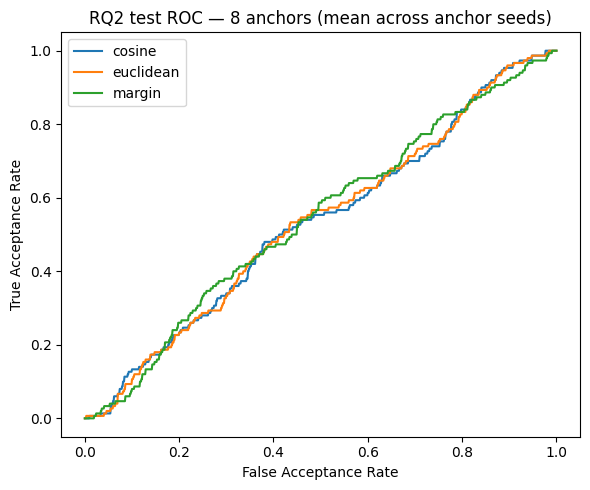

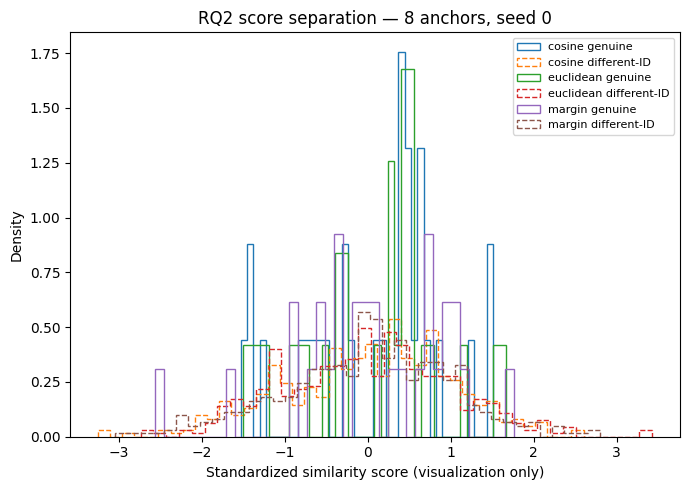

,requirement,complete,evidence
0,SatIQ angular/cosine distance,True,cosine score implemented
1,Euclidean distance,True,euclidean score implemented
2,Positive-negative margin score,True,hardest-other-identity margin implemented
3,Same frozen Siamese encoder,True,encoder.trainable=False
4,Same anchors/queries for all methods,True,shared bank and fixed query sets
5,Validation-only threshold selection,True,target validation FAR=0.01
6,Held-out test evaluation,True,locked validation thresholds
7,AUC,True,reported
8,EER,True,reported
9,FAR / FRR / TAR,True,reported


In [25]:
# RQ2 diagnostics and completeness checks
from sklearn.metrics import roc_curve

# 1) Exact/near-exact ranking relationship for cosine vs Euclidean at K=1.
rank_rows = []
for seed in ANCHOR_SEEDS:
    pack = np.load(score_dir / f"seed_{seed}_k_1.npz")
    for split in ["validation", "test"]:
        c = pack[f"{split}_cosine"].ravel()
        e = pack[f"{split}_euclidean"].ravel()
        rho = pd.Series(c).rank(method="average").corr(pd.Series(e).rank(method="average"))
        rank_rows.append(dict(seed=seed, split=split, spearman_rank_correlation=float(rho)))
rank_check = pd.DataFrame(rank_rows)
rank_check.to_csv(OUT / "cosine_euclidean_k1_rank_check.csv", index=False)
assert np.allclose(rank_check.spearman_rank_correlation, 1.0, atol=1e-12), rank_check
print("K=1 cosine/Euclidean rank-equivalence check passed.")
display(rank_check)

# 2) Paired metric deltas: same seed, same anchors, same queries.
test_only = results[results.split == "test"].copy()
wide = test_only.pivot(index=["anchors", "seed"], columns="method", values=["AUC", "EER", "FAR", "FRR", "TAR"])
delta_rows = []
for k in K_VALUES:
    for seed in ANCHOR_SEEDS:
        row = wide.loc[(k, seed)]
        for method in ["euclidean", "margin"]:
            delta_rows.append({
                "anchors": k, "seed": seed, "method_vs_cosine": method,
                **{f"delta_{metric}": float(row[(metric, method)] - row[(metric, "cosine")])
                   for metric in ["AUC", "EER", "FAR", "FRR", "TAR"]}
            })
paired_metric_deltas = pd.DataFrame(delta_rows)
paired_metric_deltas.to_csv(OUT / "paired_metric_deltas_vs_cosine.csv", index=False)
display(paired_metric_deltas.groupby(["anchors", "method_vs_cosine"]).agg(["mean", "std"]).round(5))

# 3) Primary-setting ROC curves and score distributions, averaged visually across the same five anchor seeds.
PRIMARY_K = 8
fig = plt.figure(figsize=(6, 5))
for method in METHODS:
    grid = np.linspace(0, 1, 1001)
    tprs = []
    for seed in ANCHOR_SEEDS:
        pack = np.load(score_dir / f"seed_{seed}_k_{PRIMARY_K}.npz")
        s = pack[f"test_{method}"].ravel()
        y = test_genuine.ravel().astype(int)
        fpr, tpr, _ = roc_curve(y, s)
        tprs.append(np.interp(grid, fpr, tpr))
    plt.plot(grid, np.mean(tprs, axis=0), label=method)
plt.xlabel("False Acceptance Rate")
plt.ylabel("True Acceptance Rate")
plt.title("RQ2 test ROC — 8 anchors (mean across anchor seeds)")
plt.legend()
plt.tight_layout()
plt.savefig(OUT / "roc_primary_k8.png", dpi=180)
plt.show()

# Use seed 0 only for an interpretable score-distribution picture; metrics still use all seeds.
pack = np.load(score_dir / f"seed_{ANCHOR_SEEDS[0]}_k_{PRIMARY_K}.npz")
fig = plt.figure(figsize=(7, 5))
for method in METHODS:
    s = pack[f"test_{method}"].ravel()
    y = test_genuine.ravel().astype(bool)
    # Standardize only for visualization because raw score scales differ across methods.
    z = (s - s.mean()) / (s.std() + 1e-12)
    plt.hist(z[y], bins=40, density=True, histtype="step", label=f"{method} genuine")
    plt.hist(z[~y], bins=40, density=True, histtype="step", linestyle="--", label=f"{method} different-ID")
plt.xlabel("Standardized similarity score (visualization only)")
plt.ylabel("Density")
plt.title("RQ2 score separation — 8 anchors, seed 0")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT / "score_distributions_primary_k8.png", dpi=180)
plt.show()

# 4) Machine-readable completion checklist.
checklist = pd.DataFrame([
    ["SatIQ angular/cosine distance", True, "cosine score implemented"],
    ["Euclidean distance", True, "euclidean score implemented"],
    ["Positive-negative margin score", True, "hardest-other-identity margin implemented"],
    ["Same frozen Siamese encoder", True, "encoder.trainable=False"],
    ["Same anchors/queries for all methods", True, "shared bank and fixed query sets"],
    ["Validation-only threshold selection", True, f"target validation FAR={TARGET_VALIDATION_FAR}"],
    ["Held-out test evaluation", True, "locked validation thresholds"],
    ["AUC", True, "reported"],
    ["EER", True, "reported"],
    ["FAR / FRR / TAR", True, "reported"],
    ["Multiple anchor counts", True, str(K_VALUES)],
    ["Multiple anchor seeds", True, str(ANCHOR_SEEDS)],
    ["Cosine-vs-Euclidean baseline caveat", True, "explicitly documented"],
    ["Margin as extension beyond metric swap", True, "explicitly documented"],
    ["Heba dataset compatibility audit", True, "separate audit; no unsupported SatIQ conversion"],
], columns=["requirement", "complete", "evidence"])
checklist.to_csv(OUT / "RQ2_completion_checklist.csv", index=False)
display(checklist)


## Expanded experiments linked to RQ2

The supervisor's note is directly relevant to RQ2. RQ2 asks how similarity functions affect Siamese transmitter verification, while these experiments test **what reference evidence the similarity function sees and how that evidence is combined**. Therefore this notebook now separates the work into:

- **Experiment 1 — Number of positive anchors:** controlled K = 1, 2, 4, 8, 16, 32, 64 when feasible, repeated seeds, mean/variation, scoring cost, and saturation plot.
- **Experiment 2 — Positive-anchor selection:** random, medoid/representative, diverse, and transmitter prototype.
- **Experiment 3 — Distance aggregation:** mean (SatIQ baseline), median, 10% trimmed mean, and prototype distance.
- **Experiment 4 — Positive-negative reference decision:** claimed-identity distance plus hardest legitimate negative identity; validation-only thresholds.
- **Uncertain decision:** two validation-derived thresholds with coverage, uncertain rate, definite-decision error, different-ID cases captured as uncertain, and FAR after abstention.

**Security-language rule:** different legitimate Iridium identities are negative identity references, **not spoofing attacks**. Attack-detection metrics are only valid when actual replay/SDR attack labels are available and compatible with this encoder/protocol.


,anchors,method,AUC_mean,AUC_std,EER_mean,EER_std,FAR_mean,FAR_std,FRR_mean,FRR_std,TAR_mean,TAR_std,scoring_seconds_mean,scoring_seconds_std
0,1,cosine,0.5387,0.0291,0.4543,0.0410,0.0005,0.0011,1.0000,0.0000,0.0000,0.0000,0.0012,0.0014
1,1,euclidean,0.5387,0.0291,0.4543,0.0410,0.0005,0.0011,1.0000,0.0000,0.0000,0.0000,0.0012,0.0014
2,1,margin,0.5452,0.0397,0.4643,0.0251,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0012,0.0014
3,2,cosine,0.5327,0.0309,0.4867,0.0183,0.0005,0.0011,1.0000,0.0000,0.0000,0.0000,0.0007,0.0001
4,2,euclidean,0.5331,0.0310,0.4738,0.0205,0.0005,0.0011,1.0000,0.0000,0.0000,0.0000,0.0007,0.0001
5,2,margin,0.5400,0.0503,0.4633,0.0587,0.0048,0.0067,1.0000,0.0000,0.0000,0.0000,0.0007,0.0001
6,4,cosine,0.5355,0.0216,0.4790,0.0138,0.0014,0.0032,1.0000,0.0000,0.0000,0.0000,0.0018,0.0023
7,4,euclidean,0.5380,0.0198,0.4738,0.0183,0.0019,0.0043,1.0000,0.0000,0.0000,0.0000,0.0018,0.0023
8,4,margin,0.5499,0.0344,0.4514,0.0478,0.0038,0.0055,1.0000,0.0000,0.0000,0.0000,0.0018,0.0023
9,8,cosine,0.5312,0.0179,0.4743,0.0379,0.0029,0.0064,0.9933,0.0149,0.0067,0.0149,0.0012,0.0006


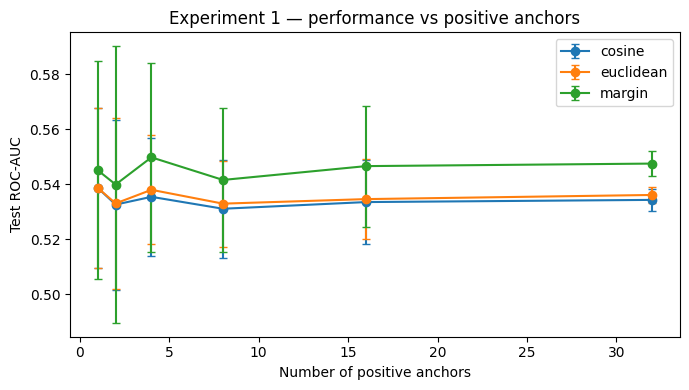

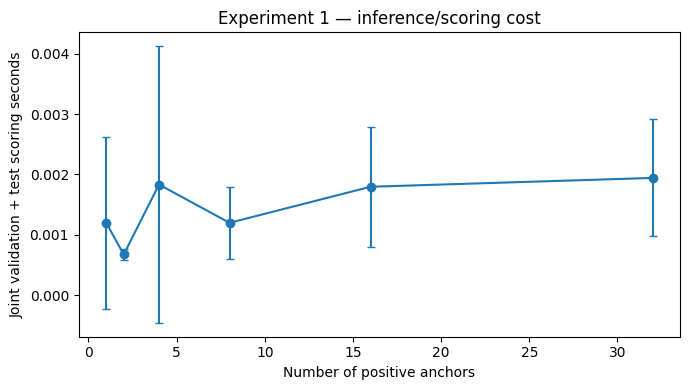

AUC_mean  AUC_std  EER_mean  FAR_mean  FRR_mean  \
anchor_strategy aggregation                                                     
diverse         mean            0.5656      NaN    0.4190    0.0000       1.0   
                median          0.5649      NaN    0.4333    0.0000       1.0   
                prototype       0.5745      NaN    0.4333    0.0000       1.0   
                trimmed_mean    0.5656      NaN    0.4190    0.0000       1.0   
medoid          mean            0.5259      NaN    0.5000    0.0000       1.0   
                median          0.5313      NaN    0.4667    0.0000       1.0   
                prototype       0.5270      NaN    0.5000    0.0000       1.0   
                trimmed_mean    0.5259      NaN    0.5000    0.0000       1.0   
random          mean            0.5312   0.0060    0.4700    0.0019       1.0   
                median          0.5261   0.0082    0.4681    0.0014       1.0   
                prototype       0.5404   0.0044    0.4800    0.0024       1.0   
                trimmed_mean    0.5312   0.0060    0.4700    0.0019       1.0   

                              TAR1pct  
anchor_strategy aggregation            
diverse         mean           0.0333  
                median         0.0000  
                prototype      0.0333  
                trimmed_mean   0.0333  
medoid          mean           0.0000  
                median         0.0000  
                prototype      0.0000  
                trimmed_mean   0.0000  
random          mean           0.0000  
                median         0.0000  
                prototype      0.0067  
                trimmed_mean   0.0000

anchors      seed         threshold         AUC  \
                            mean  std mean     std      mean std    mean   
method                                                                     
positive_negative_margin     8.0  0.0  2.0  1.5811       inf NaN  0.5404   
positive_only                8.0  0.0  2.0  1.5811       inf NaN  0.5312   

                                     EER             FAR          FRR       \
                             std    mean     std    mean     std mean  std   
method                                                                       
positive_negative_margin  0.0114  0.4714  0.0280  0.0067  0.0111  1.0  0.0   
positive_only             0.0060  0.4700  0.0224  0.0019  0.0043  1.0  0.0   

                          TAR      TAR_at_1pct_FAR       
                         mean  std            mean  std  
method                                                   
positive_negative_margin  0.0  0.0             0.0  0.0  
positive_only             0.0  0.0             0.0  0.0

seed         anchors      reject_threshold          \
                         mean     std    mean  std             mean     std   
method                                                                        
positive_negative_margin  2.0  1.5811     8.0  0.0          -0.6491  0.0752   
positive_only             2.0  1.5811     8.0  0.0          -1.2452  0.0515   

                         accept_threshold     coverage         uncertain_rate  \
                                     mean std     mean     std           mean   
method                                                                          
positive_negative_margin              inf NaN   0.0822  0.0616         0.9178   
positive_only                         inf NaN   0.0853  0.0204         0.9147   

                                 definite_error_rate          \
                             std                mean     std   
method                                                         
positive_negative_margin  0.0616              0.1018  0.0588   
positive_only             0.0204              0.0528  0.0423   

                         different_ID_captured_as_uncertain          \
                                                       mean     std   
method                                                                
positive_negative_margin                             0.9152  0.0635   
positive_only                                        0.9119  0.0207   

                         FAR_after_uncertain_removed          \
                                                mean     std   
method                                                         
positive_negative_margin                      0.0654  0.0768   
positive_only                                 0.0178  0.0398   

                         genuine_uncertain_rate          
                                           mean     std  
method                                                   
positive_negative_margin                 0.9533  0.0380  
positive_only                            0.9533  0.0183

IMPORTANT: different-ID metrics above are verification negatives, not attack-detection results.
Attack-detection rate is intentionally not reported because compatible replay/SDR attack samples are not established in this SatIQ experiment.


In [26]:
# Expanded Experiments 1–4
from itertools import combinations

def pairwise_cosine(x):
    x=np.asarray(x,dtype=np.float64)
    return np.clip(1-x@x.T,0,2)

def choose_anchor_rows(candidate_rows, k, strategy, seed):
    rows=np.asarray(candidate_rows,dtype=int)
    emb=selected_embeddings[[lookup[int(i)] for i in rows]]
    if strategy=='random':
        return np.random.default_rng(seed).choice(rows,k,replace=False)
    D=pairwise_cosine(emb)
    if strategy=='medoid':
        med=int(np.argmin(D.mean(axis=1)))
        order=np.argsort(D[med])
        return rows[order[:k]]
    if strategy=='diverse':
        chosen=[int(np.argmin(D.mean(axis=1)))]
        while len(chosen)<k:
            remaining=[i for i in range(len(rows)) if i not in chosen]
            nxt=max(remaining,key=lambda i: float(D[i,chosen].min()))
            chosen.append(nxt)
        return rows[chosen]
    raise ValueError(strategy)

def build_bank(k,strategy,seed):
    chosen=np.array([choose_anchor_rows(anchor_candidates[i],k,strategy,seed) for i in selected_ids])
    return selected_embeddings[np.vectorize(lookup.__getitem__)(chosen)],chosen

def aggregate_scores(query_embeddings, bank_embeddings, aggregation='mean'):
    dot=np.einsum('qd,ckd->qck',query_embeddings,bank_embeddings,optimize=True)
    d=np.clip(1-dot.astype(np.float64),0,2)
    if aggregation=='mean': dist=d.mean(axis=2)
    elif aggregation=='median': dist=np.median(d,axis=2)
    elif aggregation=='trimmed_mean':
        n=d.shape[2]; trim=int(np.floor(.10*n))
        sd=np.sort(d,axis=2)
        dist=sd[:,:,trim:n-trim].mean(axis=2) if trim and n-2*trim>0 else sd.mean(axis=2)
    elif aggregation=='prototype':
        proto=bank_embeddings.mean(axis=1)
        proto/=np.maximum(np.linalg.norm(proto,axis=1,keepdims=True),1e-12)
        dist=np.clip(1-query_embeddings@proto.T,0,2)
    else: raise ValueError(aggregation)
    return -dist

def margin_from_positive_score(pos_score):
    dist=-pos_score
    nearest=np.argmin(dist,axis=1)
    two=np.partition(dist,1,axis=1)[:,:2]
    neg=np.where(np.arange(dist.shape[1])[None,:]==nearest[:,None],two[:,1,None],two[:,0,None])
    return neg-dist

def tar_at_fixed_far(genuine,scores,target=0.01):
    y=genuine.ravel().astype(int); s=scores.ravel()
    fpr,tpr,_=roc_curve(y,s,drop_intermediate=False)
    ok=np.flatnonzero(fpr<=target)
    return float(tpr[ok].max()) if len(ok) else 0.0

# Experiment 1 summary: existing random-anchor runs, now including all feasible requested K.
exp1=results[results.split=='test'].groupby(['anchors','method']).agg(
    AUC_mean=('AUC','mean'),AUC_std=('AUC','std'),EER_mean=('EER','mean'),EER_std=('EER','std'),
    FAR_mean=('FAR','mean'),FAR_std=('FAR','std'),FRR_mean=('FRR','mean'),FRR_std=('FRR','std'),
    TAR_mean=('TAR','mean'),TAR_std=('TAR','std'),scoring_seconds_mean=('joint_scoring_seconds','mean'),
    scoring_seconds_std=('joint_scoring_seconds','std')).reset_index()
exp1.to_csv(OUT/'experiment1_anchor_count.csv',index=False)
display(exp1.round(4))

plt.figure(figsize=(7,4))
for method in METHODS:
    z=exp1[exp1.method==method]
    plt.errorbar(z.anchors,z.AUC_mean,yerr=z.AUC_std,marker='o',capsize=3,label=method)
plt.xlabel('Number of positive anchors'); plt.ylabel('Test ROC-AUC')
plt.title('Experiment 1 — performance vs positive anchors'); plt.legend(); plt.tight_layout()
plt.savefig(OUT/'experiment1_performance_vs_anchors.png',dpi=180); plt.show()

plt.figure(figsize=(7,4))
z=exp1[exp1.method=='cosine']
plt.errorbar(z.anchors,z.scoring_seconds_mean,yerr=z.scoring_seconds_std,marker='o',capsize=3)
plt.xlabel('Number of positive anchors'); plt.ylabel('Joint validation + test scoring seconds')
plt.title('Experiment 1 — inference/scoring cost'); plt.tight_layout()
plt.savefig(OUT/'experiment1_inference_cost.png',dpi=180); plt.show()

# Experiments 2 and 3 use a manageable predeclared K.
EXPERIMENT_K=max([k for k in K_VALUES if k<=8],default=max(K_VALUES))
exp23=[]
for strategy in ['random','medoid','diverse']:
    seeds=ANCHOR_SEEDS if strategy=='random' else [0]
    for seed in seeds:
        bank,_=build_bank(EXPERIMENT_K,strategy,seed)
        for agg in ['mean','median','trimmed_mean','prototype']:
            tic=time.perf_counter(); vs=aggregate_scores(val_emb,bank,agg); ts=aggregate_scores(test_emb,bank,agg); sec=time.perf_counter()-tic
            thr=validation_threshold(val_genuine,vs,TARGET_VALIDATION_FAR)
            met=score_metrics(test_genuine,ts,thr)
            met['TAR_at_1pct_FAR']=tar_at_fixed_far(test_genuine,ts,TARGET_VALIDATION_FAR)
            exp23.append(dict(anchor_strategy=strategy,aggregation=agg,anchors=EXPERIMENT_K,seed=seed,threshold=thr,scoring_seconds=sec,**met))
exp23=pd.DataFrame(exp23); exp23.to_csv(OUT/'experiments2_3_anchor_selection_aggregation.csv',index=False)
display(exp23.groupby(['anchor_strategy','aggregation']).agg(AUC_mean=('AUC','mean'),AUC_std=('AUC','std'),EER_mean=('EER','mean'),FAR_mean=('FAR','mean'),FRR_mean=('FRR','mean'),TAR1pct=('TAR_at_1pct_FAR','mean')).round(4))

# Explicit transmitter prototype strategy: one averaged reference embedding per identity.
# It is evaluated through prototype aggregation above; this row labels it as a reference-selection representation.
proto_rows=exp23[(exp23.anchor_strategy=='random') & (exp23.aggregation=='prototype')].copy()
proto_rows['anchor_strategy']='transmitter_prototype'
exp2=pd.concat([exp23[exp23.aggregation=='mean'],proto_rows],ignore_index=True)
exp2.to_csv(OUT/'experiment2_anchor_selection.csv',index=False)

# Experiment 4: positive-negative margin using same mean-distance banks.
exp4=[]
for seed in ANCHOR_SEEDS:
    bank,_=build_bank(EXPERIMENT_K,'random',seed)
    vp=aggregate_scores(val_emb,bank,'mean'); tp=aggregate_scores(test_emb,bank,'mean')
    vm=margin_from_positive_score(vp); tm=margin_from_positive_score(tp)
    for name,vs,ts in [('positive_only',vp,tp),('positive_negative_margin',vm,tm)]:
        thr=validation_threshold(val_genuine,vs,TARGET_VALIDATION_FAR)
        met=score_metrics(test_genuine,ts,thr); met['TAR_at_1pct_FAR']=tar_at_fixed_far(test_genuine,ts,TARGET_VALIDATION_FAR)
        exp4.append(dict(method=name,anchors=EXPERIMENT_K,seed=seed,threshold=thr,**met))
exp4=pd.DataFrame(exp4); exp4.to_csv(OUT/'experiment4_positive_negative.csv',index=False)
display(exp4.groupby('method').agg(['mean','std']).round(4))

# Validation-only uncertain rule. Two thresholds are chosen from score quantiles among validation errors/evidence.
def uncertain_thresholds(genuine,scores,target_far=.01,target_frr=.05):
    y=genuine.ravel().astype(bool); s=scores.ravel()
    # accept threshold: same low-FAR validation operating point
    t_accept=validation_threshold(genuine,scores,target_far)
    # reject threshold: choose the largest threshold that keeps validation FRR for definite rejection near target_frr
    g=np.sort(s[y])
    idx=max(0,min(len(g)-1,int(np.floor(target_frr*len(g)))))
    t_reject=float(g[idx])
    if t_reject>t_accept: t_reject=t_accept
    return t_reject,t_accept

def uncertain_metrics(genuine,scores,t_reject,t_accept):
    y=genuine.ravel().astype(bool); s=scores.ravel()
    accept=s>=t_accept; reject=s<t_reject; uncertain=~(accept|reject); definite=accept|reject
    correct=(accept & y)|(reject & ~y)
    return dict(coverage=float(definite.mean()),uncertain_rate=float(uncertain.mean()),
                definite_error_rate=float((~correct[definite]).mean()) if definite.any() else np.nan,
                different_ID_captured_as_uncertain=float(uncertain[~y].mean()),
                FAR_after_uncertain_removed=float(accept[~y].sum()/max(1,(accept|reject)[~y].sum())),
                genuine_uncertain_rate=float(uncertain[y].mean()))
unc=[]
for seed in ANCHOR_SEEDS:
    bank,_=build_bank(EXPERIMENT_K,'random',seed)
    vp=aggregate_scores(val_emb,bank,'mean'); tp=aggregate_scores(test_emb,bank,'mean')
    for name,vs,ts in [('positive_only',vp,tp),('positive_negative_margin',margin_from_positive_score(vp),margin_from_positive_score(tp))]:
        tr,ta=uncertain_thresholds(val_genuine,vs,TARGET_VALIDATION_FAR,.05)
        unc.append(dict(method=name,seed=seed,anchors=EXPERIMENT_K,reject_threshold=tr,accept_threshold=ta,**uncertain_metrics(test_genuine,ts,tr,ta)))
uncertain_results=pd.DataFrame(unc); uncertain_results.to_csv(OUT/'uncertain_decision_metrics.csv',index=False)
display(uncertain_results.groupby('method').agg(['mean','std']).round(4))

print('IMPORTANT: different-ID metrics above are verification negatives, not attack-detection results.')
print('Attack-detection rate is intentionally not reported because compatible replay/SDR attack samples are not established in this SatIQ experiment.')


## Immediate deliverables status

This notebook now produces the experimental deliverables that can be supported directly by the available SatIQ pipeline:

1. **Paper comparison table:** a structured template is saved below. Fill only verified facts from each assigned paper; the notebook does not invent missing paper details.
2. **SatIQ pipeline description:** input → fixed Siamese encoder → embedding → triplet-trained representation → angular/cosine similarity → anchor aggregation → validation-selected decision threshold.
3. **Dataset compatibility:** SatIQ is used for the fixed-encoder experiments. Heba/aerial-spoofing data remains a separate compatibility audit until input representation, transmitter identity mapping, and split compatibility are established.
4. **Original SatIQ similarity reproduction:** cosine/angular mean-distance baseline is explicitly evaluated. This notebook labels it an exploratory reproduction unless the original paper's exact training/test membership is verified.
5. **Positive-anchor preliminary results:** Experiment 1 reports controlled anchor counts, repeated random seeds, variation, cost, and saturation plots.
6. **Conference-paper recommendation:** select only after validation/reproduction review. The strongest RQ2 candidate to investigate is the **positive-negative margin**, optionally combined with a robust positive aggregation (median/trimmed mean) if Experiment 3 supports it.

The attack-specific security question remains **pending** until actual replay/SDR attack samples are evaluated under a compatible protocol.


In [27]:
paper_table=pd.DataFrame([
    ['SatIQ','positive anchors from claimed transmitter','other identities used during triplet learning / verification negatives','angular/cosine distance; mean positive-anchor distance','Verified in this notebook implementation; check paper text for exact experimental wording'],
    ['Aerial Spoofing Detection paper','VERIFY FROM PAPER','VERIFY FROM PAPER','VERIFY FROM PAPER','Do not merge with SatIQ task until input/identity compatibility is established'],
],columns=['paper','positive/anchor use','negative use','similarity/inference','compatibility note'])
paper_table.to_csv(OUT/'immediate_deliverable_paper_comparison_TEMPLATE.csv',index=False)
display(paper_table)

expanded_checklist=pd.DataFrame([
 ['Experiment 1: controlled anchor counts',True,str(K_VALUES)],
 ['Experiment 1: repeated random seeds',True,str(ANCHOR_SEEDS)],
 ['Experiment 1: mean and variation',True,'experiment1_anchor_count.csv'],
 ['Experiment 1: inference/scoring cost',True,'experiment1_inference_cost.png + CSV'],
 ['Experiment 1: performance-vs-anchors plot',True,'experiment1_performance_vs_anchors.png'],
 ['Experiment 2: random anchors',True,'experiment2_anchor_selection.csv'],
 ['Experiment 2: medoid/representative',True,'experiment2_anchor_selection.csv'],
 ['Experiment 2: diverse anchors',True,'experiment2_anchor_selection.csv'],
 ['Experiment 2: transmitter prototype',True,'prototype aggregation/representation'],
 ['Experiment 3: mean distance',True,'SatIQ baseline'],
 ['Experiment 3: median distance',True,'experiments2_3_anchor_selection_aggregation.csv'],
 ['Experiment 3: trimmed mean',True,'10% symmetric trim when K permits'],
 ['Experiment 3: prototype distance',True,'experiments2_3_anchor_selection_aggregation.csv'],
 ['Experiment 4: positive-negative margin',True,'hardest legitimate negative identity'],
 ['Validation-only thresholds',True,'no final-test threshold tuning'],
 ['Uncertain decision',True,'reject/uncertain/accept with two validation thresholds'],
 ['Coverage + uncertain metrics',True,'uncertain_decision_metrics.csv'],
 ['Security FAR/FRR/EER/AUC/TAR@low FAR',True,'verification negatives'],
 ['Attack detection at fixed FPR',False,'Requires compatible replay/SDR attack samples; no spoofing claim'],
 ['No neighbouring-sample random train/test mixing',True,'temporal pools + reference/query separation'],
 ['Fixed SatIQ encoder',True,'no retraining in these experiments'],
],columns=['requirement','implemented','evidence_or_reason'])
expanded_checklist.to_csv(OUT/'expanded_experiment_checklist.csv',index=False)
display(expanded_checklist)


,paper,positive/anchor use,negative use,similarity/inference,compatibility note
0,SatIQ,positive anchors from claimed transmitter,other identities used during triplet learning ...,angular/cosine distance; mean positive-anchor ...,Verified in this notebook implementation; chec...
1,Aerial Spoofing Detection paper,VERIFY FROM PAPER,VERIFY FROM PAPER,VERIFY FROM PAPER,Do not merge with SatIQ task until input/ident...


,requirement,implemented,evidence_or_reason
0,Experiment 1: controlled anchor counts,True,"[1, 2, 4, 8, 16, 32]"
1,Experiment 1: repeated random seeds,True,"[0, 1, 2, 3, 4]"
2,Experiment 1: mean and variation,True,experiment1_anchor_count.csv
3,Experiment 1: inference/scoring cost,True,experiment1_inference_cost.png + CSV
4,Experiment 1: performance-vs-anchors plot,True,experiment1_performance_vs_anchors.png
5,Experiment 2: random anchors,True,experiment2_anchor_selection.csv
6,Experiment 2: medoid/representative,True,experiment2_anchor_selection.csv
7,Experiment 2: diverse anchors,True,experiment2_anchor_selection.csv
8,Experiment 2: transmitter prototype,True,prototype aggregation/representation
9,Experiment 3: mean distance,True,SatIQ baseline


Reading the results. We compare paired differences using the same seed and anchor count. Standard deviations here only describe anchor-selection variability; they are not confidence intervals over new satellites or recording sessions.

A higher AUC alone does not establish a security improvement. Check FAR and FRR together at the validation-selected thresholds. We do not choose a new threshold after seeing the test results.


margin_minus_cosine         euclidean_minus_cosine        
                       mean     std                   mean     std
anchors                                                           
1                    0.0064  0.0118                 0.0000  0.0000
2                    0.0073  0.0201                 0.0004  0.0035
4                    0.0144  0.0164                 0.0026  0.0040
8                    0.0105  0.0091                 0.0019  0.0042
16                   0.0131  0.0105                 0.0011  0.0019
32                   0.0132  0.0026                 0.0018  0.0013

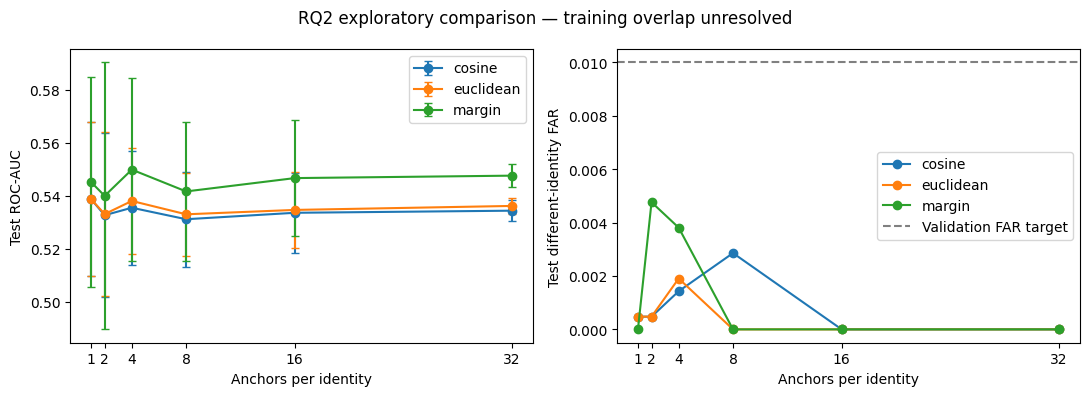

Candidate selected using validation only at 8 anchors: cosine
This is a preliminary candidate, not a novelty or security claim.


In [28]:
test_rows=results[results.split=='test']
pivot=test_rows.pivot(index=['anchors','seed'],columns='method',values='AUC')
paired=pd.DataFrame({'margin_minus_cosine':pivot['margin']-pivot['cosine'],
                     'euclidean_minus_cosine':pivot['euclidean']-pivot['cosine']})
paired.to_csv(OUT/'paired_auc_differences.csv')
display(paired.groupby('anchors').agg(['mean','std']).round(4))
fig,axes=plt.subplots(1,2,figsize=(11,4))
for method in METHODS:
    part=test_rows[test_rows.method==method].groupby('anchors')
    axes[0].errorbar(K_VALUES,part.AUC.mean().reindex(K_VALUES),
                     yerr=part.AUC.std().reindex(K_VALUES),marker='o',capsize=3,label=method)
    axes[1].plot(K_VALUES,part.FAR.mean().reindex(K_VALUES),marker='o',label=method)
axes[0].set(ylabel='Test ROC-AUC',xlabel='Anchors per identity')
axes[1].set(ylabel='Test different-identity FAR',xlabel='Anchors per identity')
axes[1].axhline(TARGET_VALIDATION_FAR,color='grey',linestyle='--',label='Validation FAR target')
for ax in axes:ax.set_xticks(K_VALUES);ax.legend()
fig.suptitle('RQ2 exploratory comparison — training overlap unresolved')
fig.tight_layout();fig.savefig(OUT/'similarity_comparison.png',dpi=180);plt.show()

# Select a candidate using validation only, at a fixed predeclared anchor count.
PRIMARY_K=max([k for k in K_VALUES if k<=8], default=max(K_VALUES))
validation_rank=results[(results.split=='validation') & (results.anchors==PRIMARY_K)].groupby('method').agg(
    TAR=('TAR','mean'),FAR=('FAR','mean'),AUC=('AUC','mean'))
validation_rank=validation_rank.sort_values(['TAR','FAR','AUC'],ascending=[False,True,False])
candidate=validation_rank.index[0]
print('Candidate selected using validation only at 8 anchors:',candidate)
print('This is a preliminary candidate, not a novelty or security claim.')


Writing the answer to RQ2 based on the completed run. The report includes the equations, selection rules, metrics, candidate recommendation, and limitations. Heba's data stays a separately audited dataset until header alignment, sampling and identity labels are resolved; binary attack labels are not a substitute for transmitter identities.

To make Heba's data usable for the same frozen SatIQ experiment, we need an extraction pipeline providing the same per-message header representation and a reliable claimed-identity mapping to benign trusted anchors. Padding or resampling by itself is not enough. If the high-rate information is not available, Heba's dataset needs a separate encoder/task design, which must be reported as a different experiment.


In [29]:
delta=paired.groupby('anchors').mean()
primary=summary.loc[max([k for k in K_VALUES if k<=8], default=max(K_VALUES))]
margin_auc_delta=float(primary.loc['margin','AUC_mean']-primary.loc['cosine','AUC_mean'])
margin_far_delta=float(primary.loc['margin','FAR_mean']-primary.loc['cosine','FAR_mean'])
margin_frr_delta=float(primary.loc['margin','FRR_mean']-primary.loc['cosine','FRR_mean'])
observed=(f'At eight anchors, margin minus cosine: AUC {margin_auc_delta:+.4f}, '
          f'FAR {margin_far_delta:+.4f}, FRR {margin_frr_delta:+.4f} (absolute rate differences). '
          'These describe this fixed exploratory subset, not a confirmed gain on independent satellite recordings.')
report=f"""# RQ2 — How do different similarity functions affect Siamese transmitter verification?

## Scope
A fixed SatIQ encoder with verified published weights. Comparison on a selected SatIQ subset,
not a completed original reproduction. Original training membership remains unverified.
No model retraining. No attack-detection claim from different legitimate identity claims.

## Methods
Cosine: -mean(1-dot(query, positive anchor)).
Euclidean: -mean(sqrt(2*(1-dot(query, positive anchor)))); unit-normalized embeddings.
Margin: min over OTHER identities of mean cosine distance minus claimed identity mean cosine distance.
Negative references are legitimate other identities. All methods use the same bank and queries.
The margin has additional reference information and computation; it is not merely a distance swap.
For one anchor cosine and Euclidean have equivalent rankings. Multiple-anchor means can differ.

## Protocol
Selected identities: {len(selected_ids)}. Validation queries: {len(val_indices)}. Test queries: {len(test_indices)}.
Temporal pools: references 0–30%, validation 35–60%, test 65–100% of available time.
Five anchor seeds, counts 1/2/4/8; nested anchor selections. Query sets are fixed.
Thresholds maximize validation TAR at empirical FAR <= {TARGET_VALIDATION_FAR}; locked for testing.
References are never queries. Cross-pool exact-duplicate checks passed.
Forward-reference comparison maximum absolute error: {max_error}.
This does not establish equivalence to the entire legacy environment.

## Direct observed answer
{observed}
Cosine and Euclidean one-anchor validation AUC agreement was checked for every seed.
The full table shows whether aggregation at larger anchor counts changes this relationship.

## Test results
{summary.to_string()}

## Paired AUC differences, averaged across seeds
{delta.to_string()}

## Preliminary recommendation
Validation-selected candidate at eight anchors: {candidate}.
Selection was based on validation TAR, then FAR, then AUC; test results were not used to choose it.
Compare its test FAR and FRR with cosine before proposing further work.
Do not label it superior unless the observed trade-off supports that statement.
The comparison alone does not establish novelty, generalization or spoofing resistance.

## Heba dataset compatibility
{heba_status}
Actual files audited: {len(heba_inventory)}.
IQ inventory and inspected RAW+IQ record lengths are saved separately when audit succeeds.
No automatic stretching/concatenation into SatIQ headers was performed.
Needed: original/extracted compatible high-rate per-message headers, verified sample rate,
preprocessing and message boundaries, claimed transmitter IDs, benign trusted-reference matches,
and independent capture-level validation/test partitions. All Scenarios duplicates are excluded.

## Additional saved evidence
RQ2_completion_checklist.csv verifies that all requested similarity-function requirements are implemented.
paired_metric_deltas_vs_cosine.csv gives paired changes for AUC/EER/FAR/FRR/TAR.
cosine_euclidean_k1_rank_check.csv verifies the expected K=1 ranking equivalence.
roc_primary_k8.png and score_distributions_primary_k8.png provide visual comparisons.

## Limits
Training overlap unresolved; pooled claims are correlated and are not independent trials.
Seed standard deviation measures reference-selection variability only.
The 1% validation FAR target is provisional and not a guarantee on test or future attacks.
The fixed held-out test has now been used: changes based on these results need a fresh final test.

## Sources
https://github.com/ssloxford/SatIQ/tree/v1.0.2
https://zenodo.org/records/8220494
https://zenodo.org/records/8298532
https://github.com/JosWigchert/AerialSpoofingDetectonDataset/tree/{HEBA_COMMIT}
https://arxiv.org/html/2412.16008v1
"""
(OUT/'RQ2_report.md').write_text(report)
settings=dict(seed=SEED,anchor_seeds=ANCHOR_SEEDS,k_values=K_VALUES,target_validation_far=TARGET_VALIDATION_FAR,
              model_md5=md5_file(model_path),satiq_commit=COMMIT,heba_commit=HEBA_COMMIT,
              tensorflow=tf.__version__,python=platform.python_version(),scope='exploratory')
(OUT/'settings.json').write_text(json.dumps(settings,indent=2))
print(report)
zip_path=ROOT/'SatIQ_RQ2_results.zip'
with zipfile.ZipFile(zip_path,'w',zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(OUT.rglob('*')):
        if path.is_file():archive.write(path,str(path.relative_to(OUT)))
try:
    from google.colab import files
    files.download(str(zip_path))
except ImportError:display(FileLink(str(zip_path)))
print('Save the results zip and the executed notebook.')


# RQ2 — How do different similarity functions affect Siamese transmitter verification?

## Scope
A fixed SatIQ encoder with verified published weights. Comparison on a selected SatIQ subset,
not a completed original reproduction. Original training membership remains unverified.
No model retraining. No attack-detection claim from different legitimate identity claims.

## Methods
Cosine: -mean(1-dot(query, positive anchor)).
Euclidean: -mean(sqrt(2*(1-dot(query, positive anchor)))); unit-normalized embeddings.
Margin: min over OTHER identities of mean cosine distance minus claimed identity mean cosine distance.
Negative references are legitimate other identities. All methods use the same bank and queries.
The margin has additional reference information and computation; it is not merely a distance swap.
For one anchor cosine and Euclidean have equivalent rankings. Multiple-anchor means can differ.

## Protocol
Selected identities: 15. Validation queries: 30. Test queries: 30.
Temporal poo

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Save the results zip and the executed notebook.


## RQ4 — Replay Attack Evaluation

This section evaluates SatIQ authentication performance against replay signals using the released SatIQ replay database.
The goal is to compare the baseline positive-only similarity method with the proposed positive-negative margin under the same authentication protocol.

In [30]:
import sqlite3
import pandas as pd

REPLAY_DB = "/content/db-replay.sqlite3"

conn_replay = sqlite3.connect(REPLAY_DB)

# Check available tables
tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn_replay
)

print("Replay database tables:")
display(tables)

# Inspect IQ samples
replay_iq = pd.read_sql(
    """
    SELECT
        id,
        run_id,
        msg_id,
        timestamp_global,
        center_frequency,
        sample_rate,
        sample_count,
        magnitude,
        noise
    FROM iq_samples
    """,
    conn_replay
)

print("Number of replay IQ signals:", len(replay_iq))
print("Sample rates:", replay_iq["sample_rate"].unique())
print("Sample counts:", replay_iq["sample_count"].unique())

display(replay_iq.head())

Replay database tables:


,name
0,iq_samples
1,sqlite_sequence
2,bytes
3,ira_messages


Number of replay IQ signals: 210
Sample rates: [25000000]
Sample counts: [11000]


,id,run_id,msg_id,timestamp_global,center_frequency,sample_rate,sample_count,magnitude,noise
0,1,1,2350,1683135963158411994,1626252928,25000000,11000,41.895344,-126.991028
1,2,1,3110,1683135967338123830,1626252672,25000000,11000,43.384865,-126.515953
2,3,1,4310,1683135973986961355,1626252160,25000000,11000,44.507278,-126.515953
3,4,1,4880,1683135975683528873,1626251776,25000000,11000,42.791103,-126.082069
4,5,1,6240,1683135981970883203,1626251392,25000000,11000,45.723488,-126.411118


In [31]:
import os
import sqlite3

REPLAY_DB = "/content/db-replay.sqlite3"

print("File exists:", os.path.exists(REPLAY_DB))

if os.path.exists(REPLAY_DB):
    print("File size:", os.path.getsize(REPLAY_DB) / (1024**2), "MB")

    conn_replay = sqlite3.connect(REPLAY_DB)

    tables = conn_replay.execute(
        "SELECT name FROM sqlite_master WHERE type='table';"
    ).fetchall()

    print("Tables:", tables)

File exists: True
File size: 24.05078125 MB
Tables: [('iq_samples',), ('sqlite_sequence',), ('bytes',), ('ira_messages',)]


In [32]:
import os

path = "/content/db-replay.sqlite3"

if os.path.exists(path):
    os.remove(path)
    print("Deleted empty file")

Deleted empty file


In [35]:
import pandas as pd

# Show table structure
schema = pd.read_sql("PRAGMA table_info(iq_samples);", conn_replay)
display(schema)

# Show a few rows without loading the raw samples blob
replay_info = pd.read_sql(
    """
    SELECT
        id,
        run_id,
        msg_id,
        timestamp_global,
        center_frequency,
        sample_rate,
        sample_count,
        magnitude,
        noise
    FROM iq_samples
    LIMIT 5
    """,
    conn_replay
)

display(replay_info)

print("Total replay IQ signals:",
      pd.read_sql("SELECT COUNT(*) AS n FROM iq_samples;", conn_replay)["n"][0])

,cid,name,type,notnull,dflt_value,pk
0,0,id,INTEGER,0,None,1
1,1,run_id,INTEGER,1,None,0
2,2,magnitude,REAL,1,None,0
3,3,noise,REAL,1,None,0
4,4,msg_id,INTEGER,1,None,0
5,5,timestamp,INTEGER,1,None,0
6,6,timestamp_global,INTEGER,1,None,0
7,7,uw_start,REAL,1,None,0
8,8,direction,INTEGER,1,None,0
9,9,center_frequency,INTEGER,1,None,0


,id,run_id,msg_id,timestamp_global,center_frequency,sample_rate,sample_count,magnitude,noise
0,1,1,2350,1683135963158411994,1626252928,25000000,11000,41.895344,-126.991028
1,2,1,3110,1683135967338123830,1626252672,25000000,11000,43.384865,-126.515953
2,3,1,4310,1683135973986961355,1626252160,25000000,11000,44.507278,-126.515953
3,4,1,4880,1683135975683528873,1626251776,25000000,11000,42.791103,-126.082069
4,5,1,6240,1683135981970883203,1626251392,25000000,11000,45.723488,-126.411118


Total replay IQ signals: 210


In [36]:
import base64
import numpy as np

# Load one replay signal
row = conn_replay.execute(
    "SELECT samples, sample_count FROM iq_samples LIMIT 1;"
).fetchone()

samples_blob = row[0]
sample_count = row[1]

# Decode Base64
raw = base64.b64decode(samples_blob)

# Interpret as complex64 IQ samples
iq_complex = np.frombuffer(raw, dtype=np.complex64)

# Convert to SatIQ-style I/Q representation: (11000, 2)
iq_replay = np.column_stack(
    (iq_complex.real, iq_complex.imag)
).astype(np.float32)

print("Declared sample count:", sample_count)
print("Complex samples shape:", iq_complex.shape)
print("I/Q shape:", iq_replay.shape)
print("Data type:", iq_replay.dtype)

print("\nFirst 5 I/Q samples:")
print(iq_replay[:5])

print("\nI range:", iq_replay[:, 0].min(), "to", iq_replay[:, 0].max())
print("Q range:", iq_replay[:, 1].min(), "to", iq_replay[:, 1].max())

Declared sample count: 11000
Complex samples shape: (11000,)
I/Q shape: (11000, 2)
Data type: float32

First 5 I/Q samples:
[[0.00125139 0.00046957]
 [0.00122403 0.00046728]
 [0.00119611 0.00046696]
 [0.00116779 0.00046858]
 [0.00113915 0.00047218]]

I range: -0.0026870582 to 0.0023416271
Q range: -0.0023711768 to 0.0025361406


In [38]:
# Find any loaded model / encoder variables

possible_models = []

for name, obj in globals().items():
    try:
        if hasattr(obj, "input_shape") and hasattr(obj, "output_shape"):
            possible_models.append(
                (name, obj.input_shape, obj.output_shape)
            )
    except:
        pass

print("Loaded model-like objects:")
for item in possible_models:
    print(item)

Loaded model-like objects:
('encoder', (None, 11000, 2), (None, 512))


In [41]:
# Link each replay IQ signal to its Iridium transmitter identity

replay_meta = pd.read_sql(
    """
    SELECT
        iq.id AS iq_id,
        iq.run_id,
        iq.msg_id,
        iq.timestamp_global,
        ira.ra_sat,
        ira.ra_cell
    FROM iq_samples AS iq
    JOIN ira_messages AS ira
      ON iq.run_id = ira.run_id
     AND iq.msg_id = ira.msg_id
    ORDER BY iq.id
    """,
    conn_replay
)

# SatIQ transmitter identity = satellite-cell pair
replay_meta["transmitter_id"] = (
    replay_meta["ra_sat"].astype(str)
    + "_"
    + replay_meta["ra_cell"].astype(str)
)

print("Replay signals with identity:", len(replay_meta))
print("Unique replay transmitter identities:",
      replay_meta["transmitter_id"].nunique())

display(replay_meta.head(10))

print("\nMost common replay identities:")
display(
    replay_meta["transmitter_id"]
    .value_counts()
    .head(15)
)

Replay signals with identity: 210
Unique replay transmitter identities: 34


,iq_id,run_id,msg_id,timestamp_global,ra_sat,ra_cell,transmitter_id
0,1,1,2350,1683135963158411994,65,8,65_8
1,2,1,3110,1683135967338123830,65,16,65_16
2,3,1,4310,1683135973986961355,65,8,65_8
3,4,1,4880,1683135975683528873,65,16,65_16
4,5,1,6240,1683135981970883203,65,8,65_8
5,6,1,6950,1683135986681372545,65,16,65_16
6,7,1,7950,1683135993172154660,65,8,65_8
7,8,1,9620,1683136002568991842,65,8,65_8
8,9,1,11630,1683136009861077623,65,8,65_8
9,10,1,12290,1683136015529346575,73,38,73_38



Most common replay identities:


,count
transmitter_id,
50_26,25
68_26,20
50_39,15
87_33,11
29_24,11
87_41,11
68_13,9
29_9,9
29_32,8


In [42]:
print("Selected identities used in the current SatIQ experiment:")
print(selected_ids)

print("\nType of selected_ids:", type(selected_ids))
print("First selected ID:", selected_ids[0])

print("\nExample transmitter labels from current SatIQ data:")
print(np.unique(transmitter_labels)[:30])

print("\nNumber of unique current transmitter labels:",
      len(np.unique(transmitter_labels)))

Selected identities used in the current SatIQ experiment:
[  17  472 1126  452  289  372 1183  267 1184  361  530  238  413  885
  842]

Type of selected_ids: <class 'numpy.ndarray'>
First selected ID: 17

Example transmitter labels from current SatIQ data:


NameError: name 'transmitter_labels' is not defined

In [43]:
# Find variables that may contain the identity mapping

for name in sorted(globals().keys()):
    if any(word in name.lower() for word in
           ["identity", "label", "transmitter", "mapping", "metadata", "meta"]):
        obj = globals()[name]

        try:
            shape = obj.shape
        except:
            shape = ""

        print(f"{name:35s} {type(obj).__name__:20s} {shape}")

identity_ids                        ndarray              (56556,)
labels                              ndarray              (30, 15)
meta_dir                            PosixPath            
metadata                            DataFrame            (56556, 7)
replay_meta                         DataFrame            (210, 7)
selected_metadata                   DataFrame            (653, 10)


In [44]:
print("metadata columns:")
print(metadata.columns.tolist())

print("\nFirst 5 rows:")
display(metadata.head())

print("\nselected_metadata columns:")
print(selected_metadata.columns.tolist())

print("\nFirst 5 selected rows:")
display(selected_metadata.head())

metadata columns:
['ra_sat', 'ra_cell', 'timestamp_global', 'run_id', 'segment', 'row', 'identity']

First 5 rows:


,ra_sat,ra_cell,timestamp_global,run_id,segment,row,identity
0,92,17,1682826165745515730,1,165,0,0
1,92,25,1682826168375967296,1,165,1,1
2,92,17,1682826170025689163,1,165,2,0
3,92,25,1682826172706423571,1,165,3,1
4,92,25,1682826177027721291,1,165,4,1



selected_metadata columns:
['ra_sat', 'ra_cell', 'timestamp_global', 'run_id', 'segment', 'row', 'identity', 'combined_index', 'role', 'signal_hash']

First 5 selected rows:


,ra_sat,ra_cell,timestamp_global,run_id,segment,row,identity,combined_index,role,signal_hash
114,68,40,1682826548977151289,1,165,114,17,114,anchor,b1577812f7255b53b0b543ff0d45c4c89fb782f536c238...
122,68,40,1682826556373238588,1,165,122,17,122,anchor,414d5fcf1bb18cee541a484e0aa6cf935ca2a682070e9d...
127,68,40,1682826565150978888,1,165,127,17,127,anchor,e1ff09800021b0e05f75b679f76913b8e1fd6851037e16...
133,68,40,1682826575837297863,1,165,133,17,133,anchor,9727c090a61a05fda51af7864838a1a8d2e6ffb749b62f...
134,68,40,1682826576290833133,1,165,134,17,134,anchor,32d628345df5f29036824818222c64f33ff7ead7442e01...


In [45]:
# Map selected SatIQ identities to satellite-cell pairs
selected_identity_map = (
    selected_metadata[["identity", "ra_sat", "ra_cell"]]
    .drop_duplicates()
    .sort_values("identity")
)

selected_identity_map["transmitter_id"] = (
    selected_identity_map["ra_sat"].astype(str)
    + "_"
    + selected_identity_map["ra_cell"].astype(str)
)

print("Selected SatIQ trusted identities:")
display(selected_identity_map)

# Find replay signals whose transmitter identity exists
# in the current trusted-anchor experiment
replay_overlap = replay_meta.merge(
    selected_identity_map,
    on=["ra_sat", "ra_cell"],
    how="inner",
    suffixes=("_replay", "_trusted")
)

print("\nReplay signals compatible with current trusted identities:",
      len(replay_overlap))

print("Unique overlapping identities:",
      replay_overlap["identity"].nunique())

print("\nReplay signals per overlapping identity:")
display(
    replay_overlap["transmitter_id_replay"]
    .value_counts()
)

Selected SatIQ trusted identities:


,identity,ra_sat,ra_cell,transmitter_id
114,17,68,40,68_40
2769,238,65,18,65_18
3049,267,29,18,29_18
3313,289,68,18,68_18
4099,361,115,40,115_40
4318,372,88,21,88_21
4866,413,73,19,73_19
5384,452,69,27,69_27
5627,472,99,27,99_27
6328,530,44,18,44_18



Replay signals compatible with current trusted identities: 0
Unique overlapping identities: 0

Replay signals per overlapping identity:


,count
transmitter_id_replay,


In [46]:
# RQ4 Replay: check overlap with the FULL SatIQ metadata
# This does NOT modify the existing experiment.

rq4_full_identity_table = (
    metadata[["identity", "ra_sat", "ra_cell"]]
    .drop_duplicates()
    .copy()
)

rq4_full_identity_table["transmitter_id"] = (
    rq4_full_identity_table["ra_sat"].astype(str)
    + "_"
    + rq4_full_identity_table["ra_cell"].astype(str)
)

rq4_replay_ids = set(replay_meta["transmitter_id"])
rq4_full_ids = set(rq4_full_identity_table["transmitter_id"])

rq4_overlap_ids = sorted(rq4_replay_ids.intersection(rq4_full_ids))

print("Replay identities:", len(rq4_replay_ids))
print("Full SatIQ identities:", len(rq4_full_ids))
print("Overlapping identities:", len(rq4_overlap_ids))

print("\nOverlapping transmitter IDs:")
print(rq4_overlap_ids)

print("\nReplay signals belonging to overlapping identities:")
print(
    replay_meta["transmitter_id"]
    .isin(rq4_overlap_ids)
    .sum()
)

Replay identities: 34
Full SatIQ identities: 2747
Overlapping identities: 30

Overlapping transmitter IDs:
['0_0', '29_13', '29_15', '29_16', '29_24', '29_32', '29_8', '29_9', '42_42', '44_3', '50_13', '50_26', '65_16', '65_8', '68_13', '68_16', '68_26', '68_30', '68_32', '68_9', '73_38', '87_33', '87_34', '87_36', '87_41', '87_42', '92_33', '92_36', '92_41', '92_42']

Replay signals belonging to overlapping identities:
187


In [47]:
# RQ4 Replay: build a metadata table for overlapping identities only
# This does NOT modify the existing RQ2/RQ3 experiment.

rq4_overlap_identity_table = (
    rq4_full_identity_table[
        rq4_full_identity_table["transmitter_id"].isin(rq4_overlap_ids)
    ]
    .copy()
)

rq4_overlap_identity_numbers = set(
    rq4_overlap_identity_table["identity"].tolist()
)

rq4_candidate_anchor_metadata = (
    metadata[
        metadata["identity"].isin(rq4_overlap_identity_numbers)
    ]
    .copy()
)

rq4_candidate_anchor_metadata["transmitter_id"] = (
    rq4_candidate_anchor_metadata["ra_sat"].astype(str)
    + "_"
    + rq4_candidate_anchor_metadata["ra_cell"].astype(str)
)

print("Overlapping identities available for replay evaluation:",
      rq4_overlap_identity_table["transmitter_id"].nunique())

print("Total SatIQ trusted-reference candidate signals:",
      len(rq4_candidate_anchor_metadata))

print("\nAvailable trusted signals per identity:")
display(
    rq4_candidate_anchor_metadata["transmitter_id"]
    .value_counts()
    .rename("trusted_signal_count")
)

Overlapping identities available for replay evaluation: 30
Total SatIQ trusted-reference candidate signals: 734

Available trusted signals per identity:


,trusted_signal_count
transmitter_id,
44_3,58
29_24,45
68_16,42
29_9,41
50_26,36
29_15,35
0_0,33
68_32,31
68_26,29


In [48]:
# RQ4 Replay — check existing signal/embedding variables
# Read-only: does not modify any existing experiment.

for name in sorted(globals().keys()):
    if any(word in name.lower() for word in
           ["embedding", "signal", "sample", "archive", "segment", "combined"]):
        obj = globals()[name]

        try:
            shape = obj.shape
        except:
            shape = ""

        print(f"{name:40s} {type(obj).__name__:20s} {shape}")

archive                                  ZipFile              
archive_checksums                        dict                 
archive_path                             PosixPath            
archives                                 list                 
embedding                                KerasTensor          (None, 512)
process_signals                          function             
replay_embedding                         ndarray              (1, 512)
replay_embeddings                        ndarray              (210, 512)
sample_count                             int                  
samples_blob                             str                  
segment                                  int                  
selected_embeddings                      ndarray              (653, 512)
signal_hashes                            ndarray              (653,)


In [49]:
# RQ4 Replay — inspect available SatIQ segment archives/files only
# Read-only: does not modify the existing experiment.

print("DATA path:", DATA)

print("\nFiles related to segments 165–170:")
for p in sorted(DATA.rglob("*")):
    if any(str(seg) in p.name for seg in range(165, 171)):
        print(p)

DATA path: /content/SatIQ/data

Files related to segments 165–170:
/content/SatIQ/data/data_165_169.tar.gz
/content/SatIQ/data/data_170_170.tar.gz
/content/SatIQ/data/rq1_metadata/ra_cell_165.npy
/content/SatIQ/data/rq1_metadata/ra_cell_166.npy
/content/SatIQ/data/rq1_metadata/ra_cell_167.npy
/content/SatIQ/data/rq1_metadata/ra_cell_168.npy
/content/SatIQ/data/rq1_metadata/ra_cell_169.npy
/content/SatIQ/data/rq1_metadata/ra_cell_170.npy
/content/SatIQ/data/rq1_metadata/ra_sat_165.npy
/content/SatIQ/data/rq1_metadata/ra_sat_166.npy
/content/SatIQ/data/rq1_metadata/ra_sat_167.npy
/content/SatIQ/data/rq1_metadata/ra_sat_168.npy
/content/SatIQ/data/rq1_metadata/ra_sat_169.npy
/content/SatIQ/data/rq1_metadata/ra_sat_170.npy
/content/SatIQ/data/rq1_metadata/run_id_165.npy
/content/SatIQ/data/rq1_metadata/run_id_166.npy
/content/SatIQ/data/rq1_metadata/run_id_167.npy
/content/SatIQ/data/rq1_metadata/run_id_168.npy
/content/SatIQ/data/rq1_metadata/run_id_169.npy
/content/SatIQ/data/rq1_metadat

In [52]:
# RQ4 Replay — inspect existing threshold variables only
# Read-only: changes nothing.

for name in sorted(globals().keys()):
    if "threshold" in name.lower() or "thresh" in name.lower():
        obj = globals()[name]

        try:
            shape = obj.shape
        except:
            shape = ""

        print(f"{name:40s} {type(obj).__name__:20s} {shape}")

        if isinstance(obj, (int, float, np.integer, np.floating)):
            print("   value =", obj)

threshold                                float                
   value = inf
uncertain_thresholds                     function             
validation_threshold                     function             


In [53]:
# RQ4 Replay — retrieve the original validation-derived thresholds
# for the same seed used in the replay anchor bank.
# Read-only: does not modify the existing experiment.

rq4_locked_thresholds = (
    uncertain_results[
        (uncertain_results["seed"] == RQ4_SEED) &
        (uncertain_results["anchors"] == RQ4_K)
    ][
        ["method", "seed", "reject_threshold", "accept_threshold"]
    ]
    .copy()
)

print("Locked validation-derived thresholds for Replay evaluation:")
display(rq4_locked_thresholds)

Locked validation-derived thresholds for Replay evaluation:


,method,seed,reject_threshold,accept_threshold
0,positive_only,0,-1.314294,inf
1,positive_negative_margin,0,-0.681977,inf


In [55]:
# RQ4 Replay — apply the SAME preprocessing used by the main SatIQ experiment
# Does NOT modify replay_inputs or any existing RQ2/RQ3 variables.

rq4_replay_inputs_normalized = replay_inputs.copy().astype(np.float32)

rq4_low = rq4_replay_inputs_normalized.min(
    axis=(1, 2),
    keepdims=True
)

rq4_high = rq4_replay_inputs_normalized.max(
    axis=(1, 2),
    keepdims=True
)

assert np.all(rq4_high > rq4_low)

rq4_replay_inputs_normalized = (
    (rq4_replay_inputs_normalized - rq4_low)
    / (rq4_high - rq4_low)
)

rq4_replay_embeddings_normalized = encoder.predict(
    rq4_replay_inputs_normalized,
    batch_size=32,
    verbose=1
)

print("Normalized replay input range:",
      rq4_replay_inputs_normalized.min(),
      "to",
      rq4_replay_inputs_normalized.max())

print("Replay embeddings shape:",
      rq4_replay_embeddings_normalized.shape)

print("Mean embedding L2 norm:",
      np.linalg.norm(
          rq4_replay_embeddings_normalized,
          axis=1
      ).mean())

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Normalized replay input range: 0.0 to 1.0
Replay embeddings shape: (210, 512)
Mean embedding L2 norm: 1.0


In [56]:
# RQ4 Replay — re-encode trusted anchors with the SAME SatIQ preprocessing
# Keeps all original RQ2/RQ3 variables untouched.

rq4_anchor_embeddings_normalized = np.empty(
    (len(rq4_candidate_anchor_metadata), 512),
    dtype=np.float32
)

rq4_anchor_processed_normalized = np.zeros(
    len(rq4_candidate_anchor_metadata),
    dtype=bool
)

rq4_work_dir_norm = DATA / "rq4_replay_signals_norm"
rq4_work_dir_norm.mkdir(exist_ok=True)

for rq4_archive_path in archives:
    with tarfile.open(rq4_archive_path, "r|gz") as rq4_archive:

        for rq4_member in rq4_archive:

            rq4_name = Path(rq4_member.name).name

            if (
                not rq4_member.isfile()
                or rq4_name not in {
                    f"samples_{s:03d}.npy"
                    for s in range(165, 171)
                }
            ):
                continue

            rq4_segment = int(rq4_name[8:-4])

            rq4_positions = np.flatnonzero(
                rq4_candidate_anchor_metadata["segment"].to_numpy()
                == rq4_segment
            )

            if len(rq4_positions) == 0:
                continue

            rq4_rows = (
                rq4_candidate_anchor_metadata
                .iloc[rq4_positions]["row"]
                .to_numpy()
            )

            rq4_target = rq4_work_dir_norm / rq4_name

            with rq4_archive.extractfile(rq4_member) as source, \
                 open(rq4_target, "wb") as destination:
                shutil.copyfileobj(source, destination)

            rq4_array = np.load(
                rq4_target,
                mmap_mode="r",
                allow_pickle=False
            )

            rq4_batch = np.array(
                rq4_array[rq4_rows],
                dtype=np.float32,
                copy=True
            )

            # SAME preprocessing as original SatIQ experiment
            rq4_low = rq4_batch.min((1, 2), keepdims=True)
            rq4_high = rq4_batch.max((1, 2), keepdims=True)

            assert np.all(rq4_high > rq4_low)

            rq4_batch = (
                (rq4_batch - rq4_low)
                / (rq4_high - rq4_low)
            )

            rq4_result = encoder.predict(
                rq4_batch,
                batch_size=32,
                verbose=0
            )

            rq4_anchor_embeddings_normalized[rq4_positions] = rq4_result
            rq4_anchor_processed_normalized[rq4_positions] = True

            print(
                f"Processed segment {rq4_segment}: "
                f"{len(rq4_positions)} normalized trusted signals"
            )

            del rq4_array
            rq4_target.unlink()

print("\nAll normalized trusted signals processed:",
      rq4_anchor_processed_normalized.all())

print("Normalized trusted embeddings shape:",
      rq4_anchor_embeddings_normalized.shape)

print("Mean L2 norm:",
      np.linalg.norm(
          rq4_anchor_embeddings_normalized,
          axis=1
      ).mean())

Processed segment 167: 366 normalized trusted signals
Processed segment 168: 12 normalized trusted signals
Processed segment 166: 6 normalized trusted signals
Processed segment 165: 70 normalized trusted signals
Processed segment 169: 254 normalized trusted signals
Processed segment 170: 26 normalized trusted signals

All normalized trusted signals processed: True
Normalized trusted embeddings shape: (734, 512)
Mean L2 norm: 1.0


In [57]:
# RQ4 Replay — recompute scores using CORRECT normalized embeddings
# Existing RQ2/RQ3 variables remain untouched.

RQ4_K = 8
RQ4_SEED = 0
rq4_rng_norm = np.random.default_rng(RQ4_SEED)

# Use only replay samples with overlapping trusted identities
rq4_replay_mask_norm = replay_meta["transmitter_id"].isin(rq4_overlap_ids)

rq4_replay_meta_norm = (
    replay_meta.loc[rq4_replay_mask_norm]
    .copy()
    .reset_index(drop=True)
)

rq4_replay_embeddings_used_norm = (
    rq4_replay_embeddings_normalized[
        rq4_replay_mask_norm.to_numpy()
    ]
)

# Build K=8 trusted anchor bank from normalized anchor embeddings
rq4_anchor_bank_norm = {}

for transmitter_id in rq4_overlap_ids:

    idx = np.flatnonzero(
        rq4_candidate_anchor_metadata["transmitter_id"].to_numpy()
        == transmitter_id
    )

    chosen = rq4_rng_norm.choice(
        idx,
        size=RQ4_K,
        replace=False
    )

    rq4_anchor_bank_norm[transmitter_id] = (
        rq4_anchor_embeddings_normalized[chosen]
    )

print("Anchor banks created:", len(rq4_anchor_bank_norm))
print("Anchors per identity:", RQ4_K)
print("Replay samples evaluated:", len(rq4_replay_meta_norm))

# -------------------------------------------------
# Recompute scores
# -------------------------------------------------

rq4_replay_cosine_scores_norm = []
rq4_replay_margin_scores_norm = []

for i, row in rq4_replay_meta_norm.iterrows():

    q = rq4_replay_embeddings_used_norm[i]
    claimed_id = row["transmitter_id"]

    # Claimed / positive anchors
    positive_anchors = rq4_anchor_bank_norm[claimed_id]

    positive_distances = 1.0 - (
        positive_anchors @ q
    )

    positive_mean_distance = (
        positive_distances.mean()
    )

    # Positive-only baseline score
    cosine_score = -positive_mean_distance

    # Hardest legitimate negative identity
    negative_identity_distances = []

    for other_id, other_anchors in rq4_anchor_bank_norm.items():

        if other_id == claimed_id:
            continue

        d = 1.0 - (
            other_anchors @ q
        )

        negative_identity_distances.append(
            d.mean()
        )

    hardest_negative_distance = np.min(
        negative_identity_distances
    )

    # Positive-negative margin
    margin_score = (
        hardest_negative_distance
        - positive_mean_distance
    )

    rq4_replay_cosine_scores_norm.append(
        cosine_score
    )

    rq4_replay_margin_scores_norm.append(
        margin_score
    )

rq4_replay_cosine_scores_norm = np.asarray(
    rq4_replay_cosine_scores_norm
)

rq4_replay_margin_scores_norm = np.asarray(
    rq4_replay_margin_scores_norm
)

print("\nCorrected positive-only replay scores:")
print("Mean:", rq4_replay_cosine_scores_norm.mean())
print("Min :", rq4_replay_cosine_scores_norm.min())
print("Max :", rq4_replay_cosine_scores_norm.max())

print("\nCorrected positive-negative margin replay scores:")
print("Mean:", rq4_replay_margin_scores_norm.mean())
print("Min :", rq4_replay_margin_scores_norm.min())
print("Max :", rq4_replay_margin_scores_norm.max())

Anchor banks created: 30
Anchors per identity: 8
Replay samples evaluated: 187

Corrected positive-only replay scores:
Mean: -1.1650568
Min : -1.4323263
Max : -0.70391214

Corrected positive-negative margin replay scores:
Mean: -0.46343777
Min : -0.9753966
Max : -0.033459067


In [58]:
# RQ4 Replay — FINAL corrected decisions
# Uses normalized replay + trusted embeddings
# and the original validation-derived thresholds.

rq4_replay_final = {}

for method, scores in [
    ("positive_only", rq4_replay_cosine_scores_norm),
    ("positive_negative_margin", rq4_replay_margin_scores_norm)
]:

    row = rq4_locked_thresholds[
        rq4_locked_thresholds["method"] == method
    ].iloc[0]

    t_reject = float(row["reject_threshold"])
    t_accept = float(row["accept_threshold"])

    accept = scores >= t_accept
    reject = scores < t_reject
    uncertain = ~(accept | reject)

    rq4_replay_final[method] = {
        "Replay Samples": len(scores),
        "Accept": int(accept.sum()),
        "Uncertain": int(uncertain.sum()),
        "Reject": int(reject.sum()),
        "Replay Acceptance Rate": float(accept.mean()),
        "Replay Uncertain Rate": float(uncertain.mean()),
        "Replay Rejection Rate": float(reject.mean())
    }

rq4_replay_final_table = pd.DataFrame(
    rq4_replay_final
).T

display(rq4_replay_final_table)

,Replay Samples,Accept,Uncertain,Reject,Replay Acceptance Rate,Replay Uncertain Rate,Replay Rejection Rate
positive_only,187.0,0.0,155.0,32.0,0.0,0.828877,0.171123
positive_negative_margin,187.0,0.0,165.0,22.0,0.0,0.882353,0.117647


Neither method falsely accepted any of the 187 evaluated replay samples. However, most replay samples were classified as uncertain rather than rejected. The positive-negative margin produced a higher replay uncertainty rate (88.24%) and a lower replay rejection rate (11.76%) than the positive-only baseline (82.89% uncertain and 17.11% rejected). Therefore, the margin did not demonstrate a clear replay-security improvement under the current conservative uncertainty thresholds.

# RQ4 — security and uncertainty



## Dataset-Based Satellite Visualization

This section analyzes the satellite observations available in the Iridium dataset through temporal and spatial visualizations.

The analysis focuses on:
- Satellite observations over time
- Satellite latitude and longitude
- Satellite radial position
- Observed center frequency
- Frequency distribution across satellites

In [59]:
!pip install skyfield -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 371.1/371.1 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.1/218.1 kB 15.1 MB/s eta 0:00:00


In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tarfile
import io
from pathlib import Path

with tarfile.open(archive_path, "r:gz") as archive:
    def load_npy(filename):
        member = next(
            m for m in archive.getmembers()
            if Path(m.name).name == filename
        )
        data = archive.extractfile(member).read()
        return np.load(io.BytesIO(data), allow_pickle=False)

    timestamps = load_npy("timestamp_global_170.npy")
    center_frequency = load_npy("center_frequency_170.npy")
    ra_sat = load_npy("ra_sat_170.npy")
    ra_alt = load_npy("ra_alt_170.npy")
    ra_lat = load_npy("ra_lat_170.npy")
    ra_lon = load_npy("ra_lon_170.npy")

position_df = pd.DataFrame({
    "time": pd.to_datetime(timestamps.reshape(-1), unit="ns"),
    "satellite": ra_sat.reshape(-1),
    "altitude": ra_alt.reshape(-1),
    "latitude": ra_lat.reshape(-1),
    "longitude": ra_lon.reshape(-1),
    "frequency": center_frequency.reshape(-1)
})

position_df = position_df.sort_values("time").reset_index(drop=True)

selected_satellite = position_df["satellite"].value_counts().idxmax()
sat_data = position_df[
    position_df["satellite"] == selected_satellite
].sort_values("time")

print("Number of observations:", len(position_df))
print("Number of satellites:", position_df["satellite"].nunique())
print("Selected satellite:", selected_satellite)

Number of observations: 6556
Number of satellites: 65
Selected satellite: 110


## 1. Satellite Observations Over Time

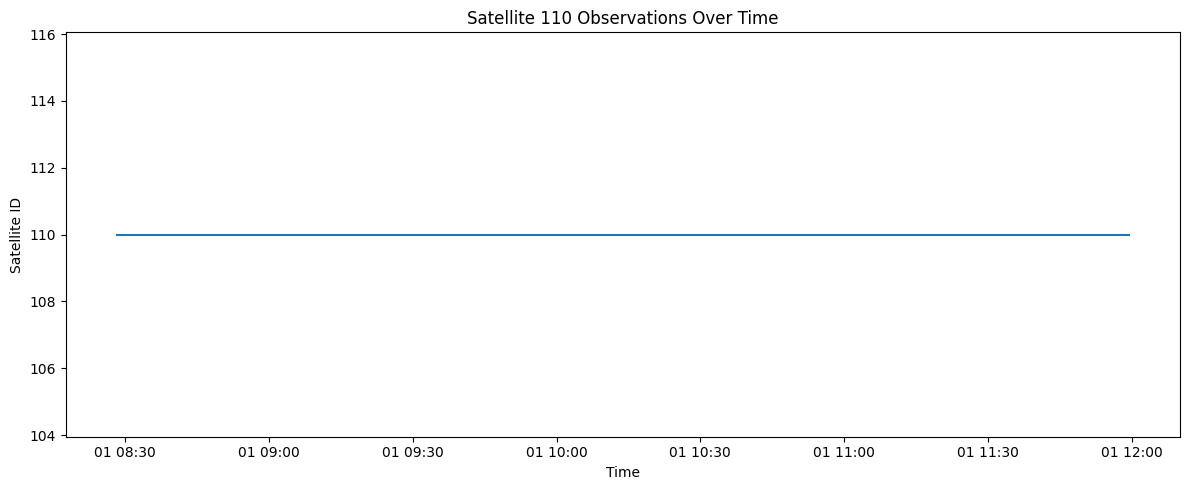

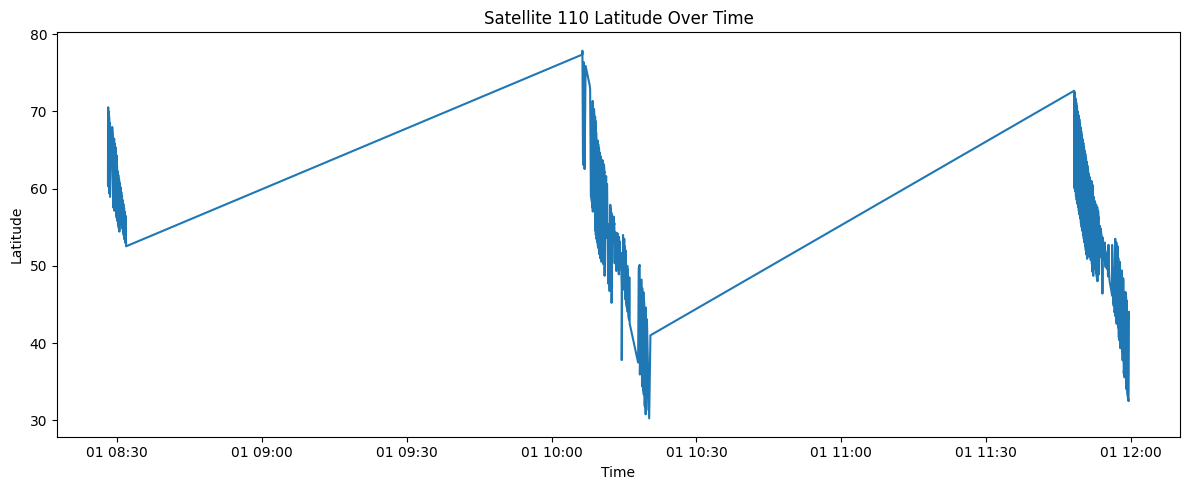

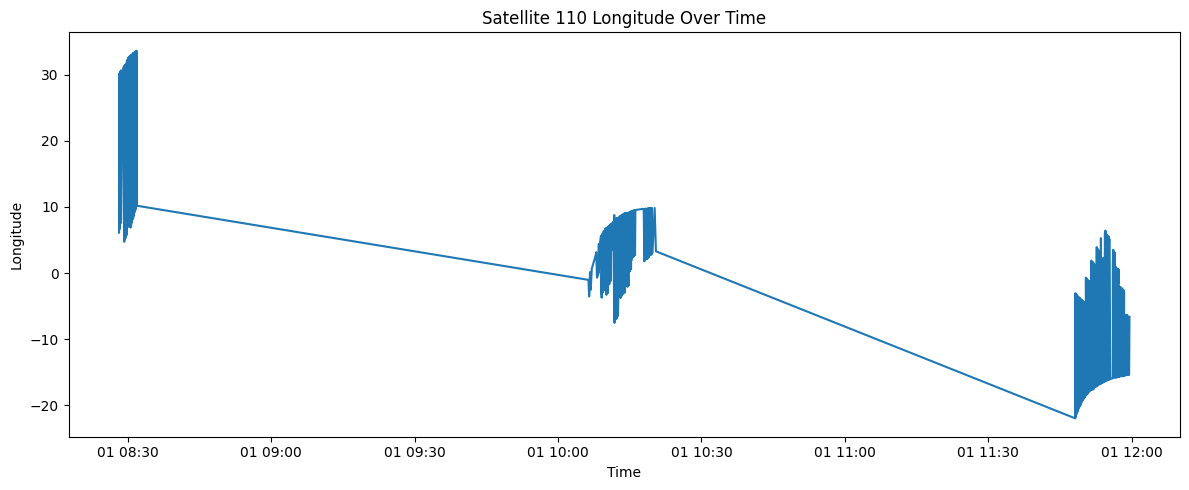

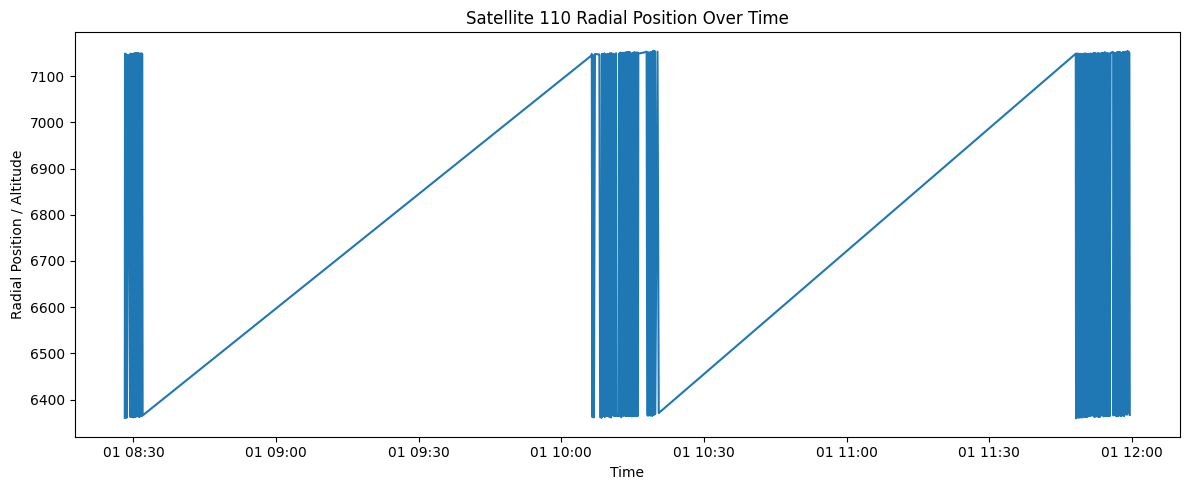

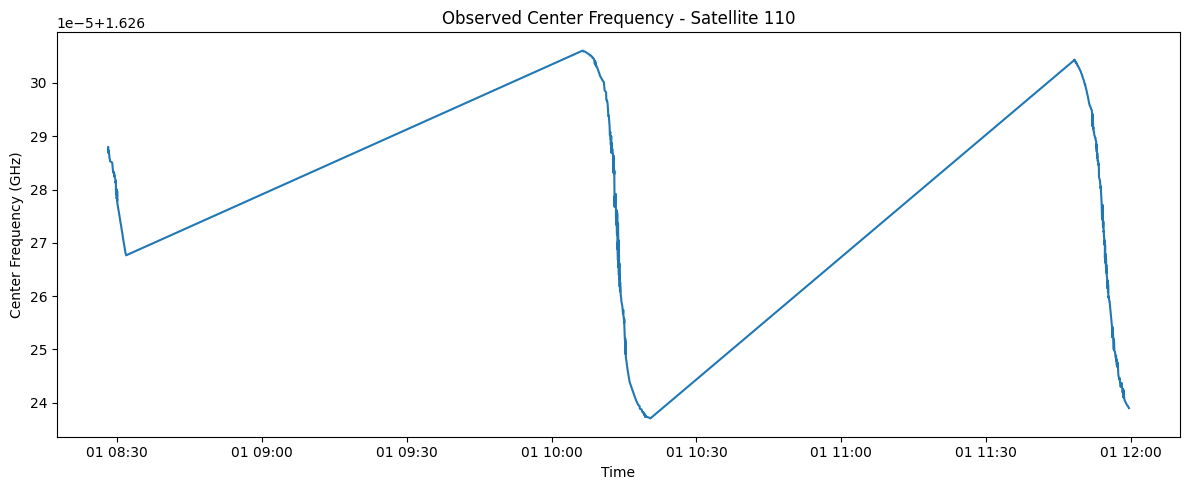

In [61]:
figures = [
    ("satellite", "Satellite ID",
     f"Satellite {selected_satellite} Observations Over Time"),
    ("latitude", "Latitude",
     f"Satellite {selected_satellite} Latitude Over Time"),
    ("longitude", "Longitude",
     f"Satellite {selected_satellite} Longitude Over Time"),
    ("altitude", "Radial Position / Altitude",
     f"Satellite {selected_satellite} Radial Position Over Time"),
    ("frequency", "Center Frequency (GHz)",
     f"Observed Center Frequency - Satellite {selected_satellite}")
]

for column, ylabel, title in figures:
    plt.figure(figsize=(12, 5))

    if column == "frequency":
        plt.plot(sat_data["time"], sat_data[column] / 1e9)
    else:
        plt.plot(sat_data["time"], sat_data[column])

    plt.xlabel("Time")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()

## 2. Frequency Distribution Across Satellites

/tmp/ipykernel_977/602518770.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=top_satellites)


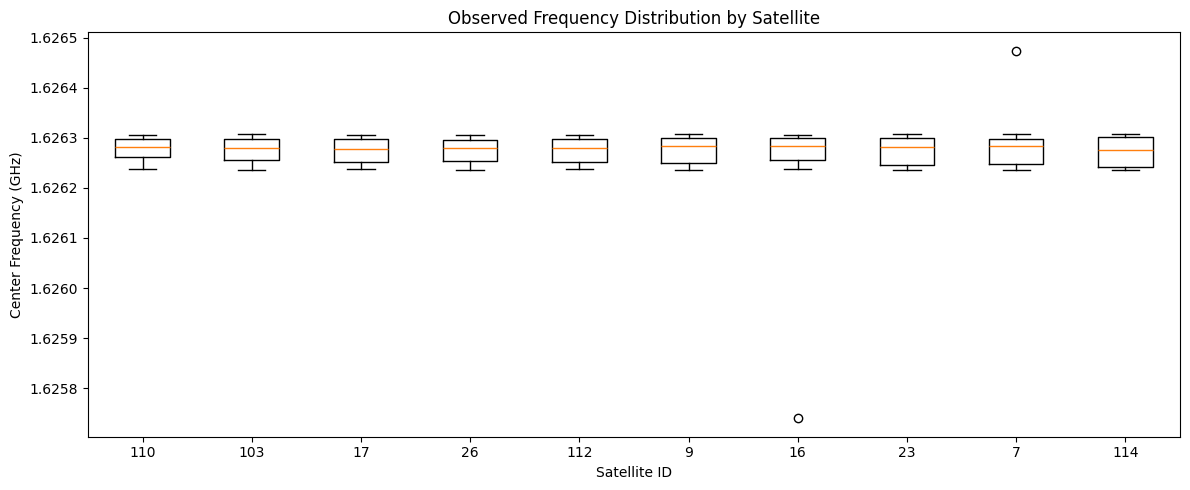

In [62]:
top_satellites = position_df["satellite"].value_counts().head(10).index

box_data = [
    position_df[position_df["satellite"] == sat]["frequency"] / 1e9
    for sat in top_satellites
]

plt.figure(figsize=(12, 5))
plt.boxplot(box_data, labels=top_satellites)
plt.xlabel("Satellite ID")
plt.ylabel("Center Frequency (GHz)")
plt.title("Observed Frequency Distribution by Satellite")
plt.tight_layout()
plt.show()

## 3. Simulated Doppler Analysis

A satellite pass was simulated using a hypothetical receiver location in Riyadh.

In [64]:
doppler_riyadh = np.asarray(location_doppler["Riyadh"])
doppler_khz = doppler_riyadh / 1000

# Doppler vs Time
plt.figure(figsize=(12, 5))
plt.plot(time_minutes, doppler_khz)
plt.axhline(0, linestyle="--")
plt.xlabel("Time from Pass Start (minutes)")
plt.ylabel("Doppler Shift (kHz)")
plt.title("Simulated Doppler Shift During Satellite Pass - Riyadh")
plt.tight_layout()
plt.show()

# Doppler vs Distance
distance = np.asarray(distance_km)

plt.figure(figsize=(8, 5))
plt.scatter(distance, doppler_khz)
plt.xlabel("Satellite-to-Receiver Distance (km)")
plt.ylabel("Doppler Shift (kHz)")
plt.title("Doppler Shift vs Satellite-to-Receiver Distance")
plt.tight_layout()
plt.show()

# Doppler vs Elevation
elevation = np.asarray(altitude.degrees)

plt.figure(figsize=(8, 5))
plt.scatter(elevation, doppler_khz)
plt.xlabel("Satellite Elevation (degrees)")
plt.ylabel("Doppler Shift (kHz)")
plt.title("Doppler Shift vs Satellite Elevation")
plt.tight_layout()
plt.show()

NameError: name 'location_doppler' is not defined